## New York Taxi Trip Duration Regression

### Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [5]:
%config InlineBackend.figure_format = 'retina'

### Loading Dataset

In [6]:
df = pd.read_csv("data/NYC.csv")

df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 122.4 MB


### Handling Null Values, Duplicates and unncessairy columns

In [8]:
print(df.isnull().sum())
print(df.duplicated().sum())

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64
0


In [9]:
## id is irrelevant for the model
## dropoff_datetime to prevent data leakage
df.drop(columns=["dropoff_datetime", "id"], inplace=True)

### Date Feature Engineering

In [10]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["pickup_hour"] = df["pickup_datetime"].dt.hour
df["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek
df["pickup_month"] = df["pickup_datetime"].dt.month
df["is_weekend"] = df["pickup_dayofweek"] >= 5

In [11]:
df[[
    "pickup_datetime",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "is_weekend"
]].head()

,pickup_datetime,pickup_hour,pickup_dayofweek,pickup_month,is_weekend
0,2016-03-14 17:24:55,17,0,3,False
1,2016-06-12 00:43:35,0,6,6,True
2,2016-01-19 11:35:24,11,1,1,False
3,2016-04-06 19:32:31,19,2,4,False
4,2016-03-26 13:30:55,13,5,3,True


In [12]:
df = df.drop(columns=["pickup_datetime"])

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 12 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   vendor_id           1458644 non-null  int64  
 1   passenger_count     1458644 non-null  int64  
 2   pickup_longitude    1458644 non-null  float64
 3   pickup_latitude     1458644 non-null  float64
 4   dropoff_longitude   1458644 non-null  float64
 5   dropoff_latitude    1458644 non-null  float64
 6   store_and_fwd_flag  1458644 non-null  str    
 7   trip_duration       1458644 non-null  int64  
 8   pickup_hour         1458644 non-null  int32  
 9   pickup_dayofweek    1458644 non-null  int32  
 10  pickup_month        1458644 non-null  int32  
 11  is_weekend          1458644 non-null  bool   
dtypes: bool(1), float64(4), int32(3), int64(3), str(1)
memory usage: 107.1 MB


In [14]:
df['trip_duration'].describe()

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

In [15]:
df.sort_values(by='trip_duration', ascending=False).head(10)

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_dayofweek,pickup_month,is_weekend
978383,1,1,-73.783905,40.648632,-73.978271,40.750202,N,3526282,22,5,2,True
924150,1,1,-73.983788,40.742325,-73.985489,40.727676,N,2227612,6,1,1,False
680594,1,2,-73.921677,40.735252,-73.984749,40.759979,N,2049578,22,5,2,True
355003,1,1,-73.789650,40.643559,-73.956810,40.773087,N,1939736,0,1,1,False
1234291,2,2,-73.794525,40.644825,-73.991051,40.755573,N,86392,23,0,2,False
295382,2,1,-73.781952,40.644688,-73.993874,40.745926,N,86391,13,1,5,False
73816,2,1,-73.996010,40.753220,-73.979027,40.740601,N,86390,0,4,5,False
59891,2,1,-73.992279,40.749729,-73.962524,40.800770,N,86387,16,3,6,False
1360439,2,1,-73.782089,40.644806,-73.985016,40.666828,N,86385,16,3,6,False
753765,2,4,-74.006111,40.734680,-73.958809,40.815449,N,86379,22,1,5,False


In [16]:
Q1 = df["trip_duration"].quantile(0.25)
Q3 = df["trip_duration"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

max_non_outlier = df.loc[
    df["trip_duration"] <= upper_bound,
    "trip_duration"
].max()

print("Upper bound:", upper_bound)
print("Maximum non-outlier:", max_non_outlier)

Upper bound: 2092.0
Maximum non-outlier: 2092


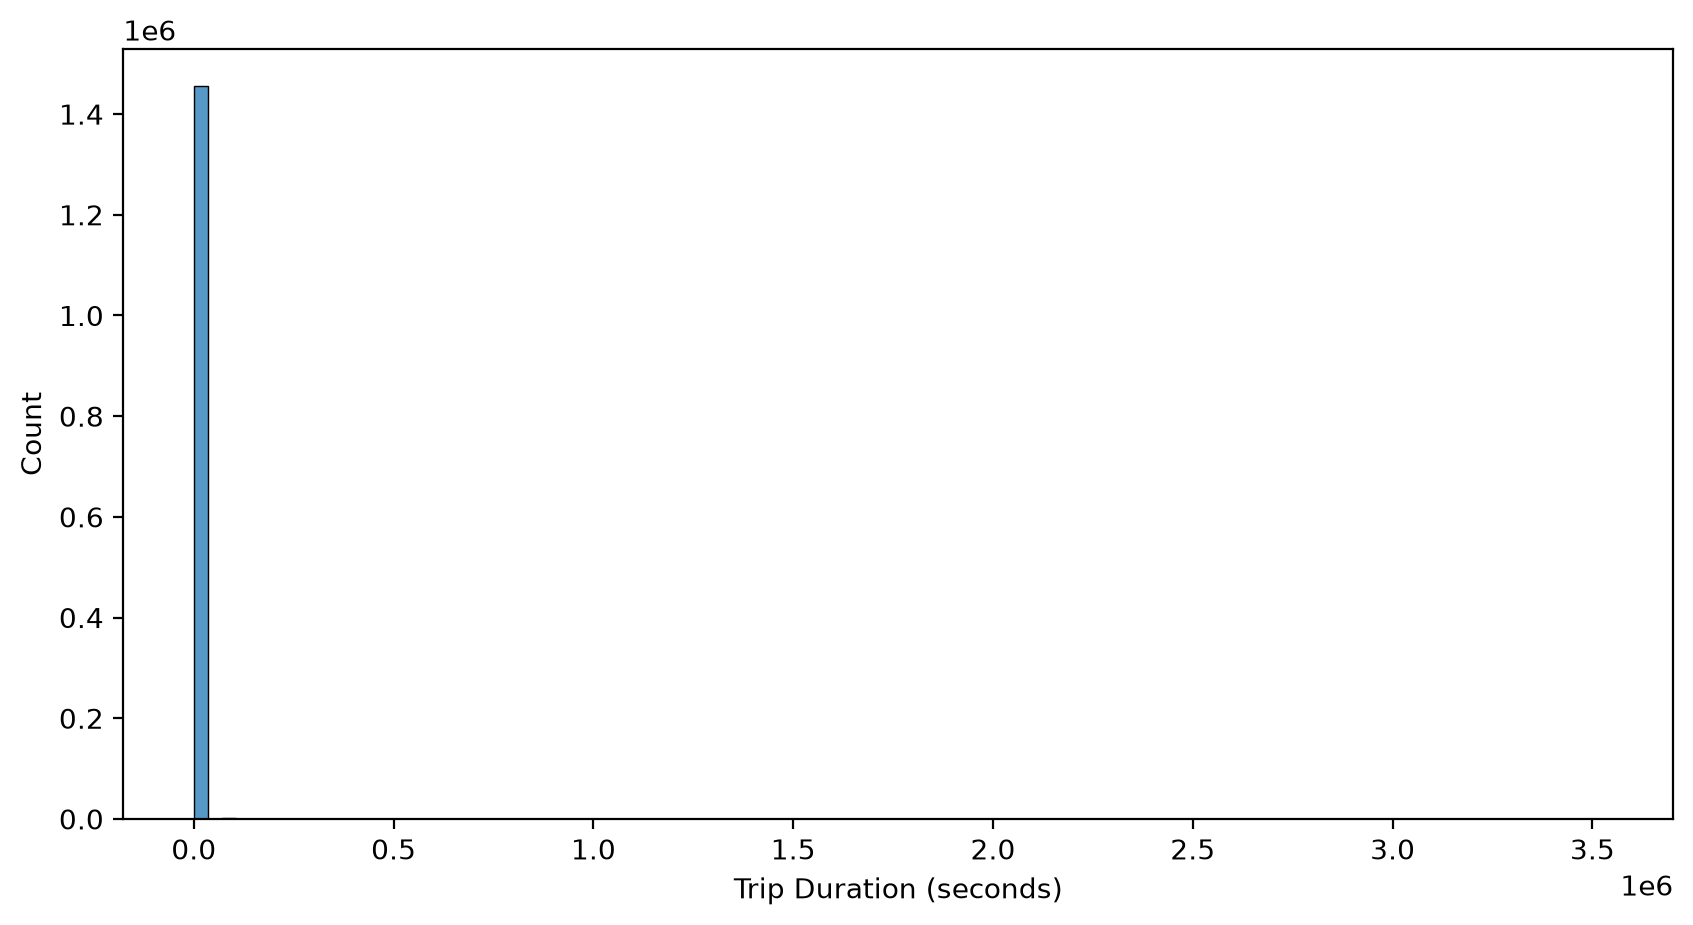

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(df["trip_duration"], bins=100)
plt.xlabel("Trip Duration (seconds)")
plt.show()

In [18]:
print(
    len(df[df["trip_duration"] > 4000]) / len(df) * 100
)

0.5686102983318754


In [19]:
df =df[df["trip_duration"] <= 4000]

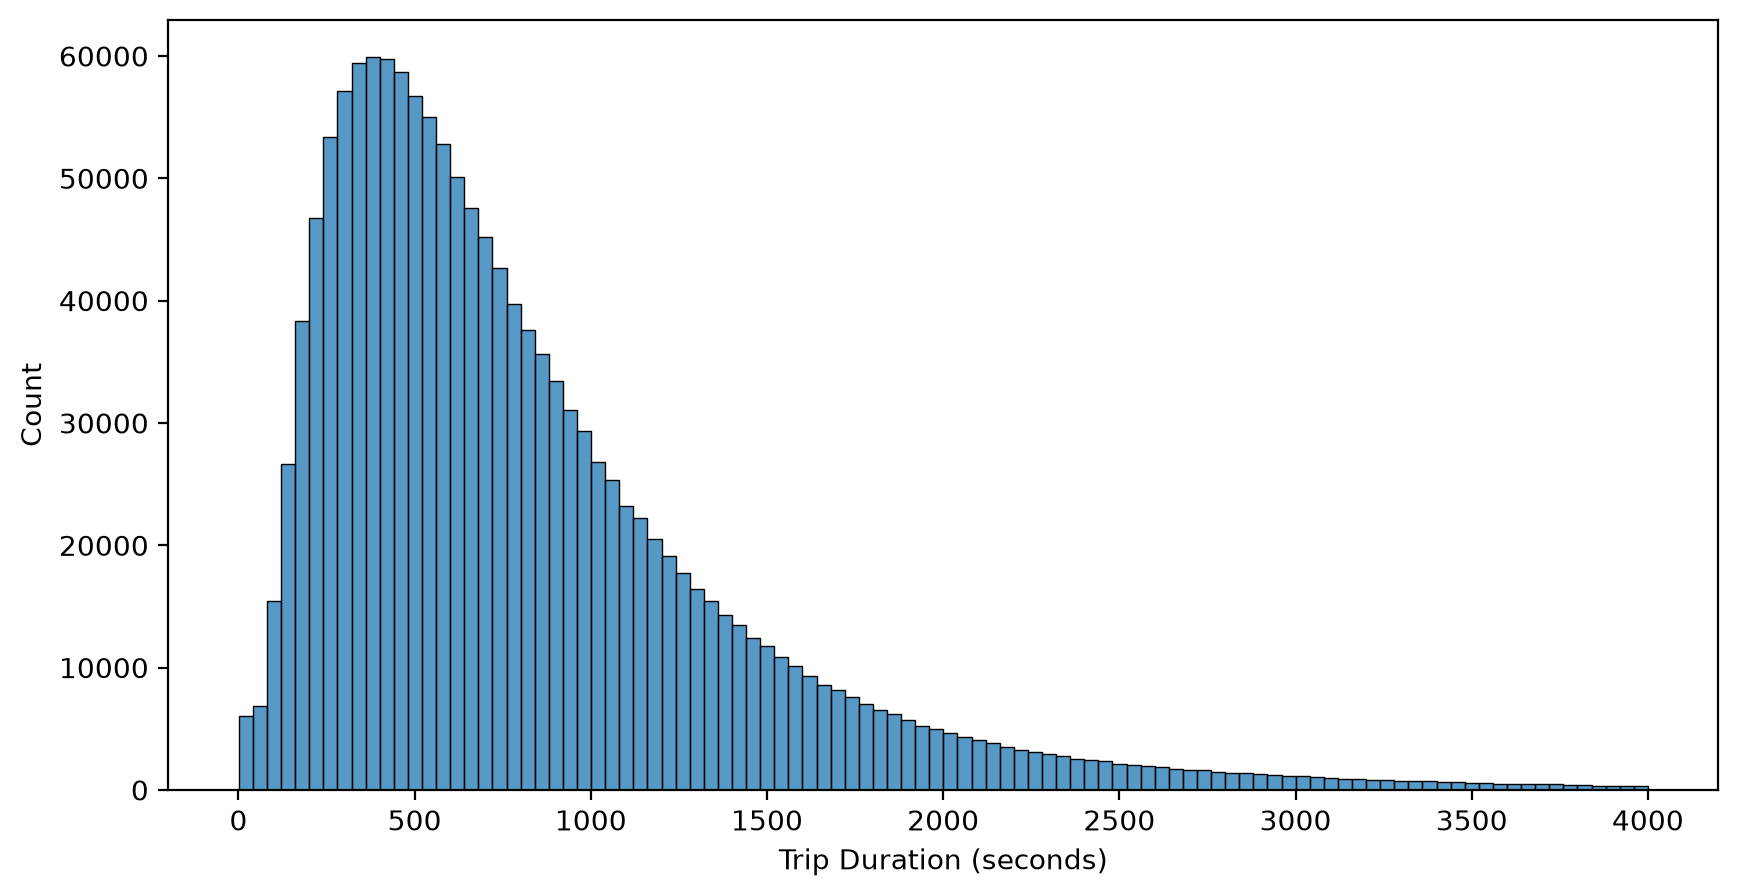

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(df["trip_duration"], bins=100)
plt.xlabel("Trip Duration (seconds)")
plt.show()

### Transforming rest of data to numerical values

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 1450350 entries, 0 to 1458643
Data columns (total 12 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   vendor_id           1450350 non-null  int64  
 1   passenger_count     1450350 non-null  int64  
 2   pickup_longitude    1450350 non-null  float64
 3   pickup_latitude     1450350 non-null  float64
 4   dropoff_longitude   1450350 non-null  float64
 5   dropoff_latitude    1450350 non-null  float64
 6   store_and_fwd_flag  1450350 non-null  str    
 7   trip_duration       1450350 non-null  int64  
 8   pickup_hour         1450350 non-null  int32  
 9   pickup_dayofweek    1450350 non-null  int32  
 10  pickup_month        1450350 non-null  int32  
 11  is_weekend          1450350 non-null  bool   
dtypes: bool(1), float64(4), int32(3), int64(3), str(1)
memory usage: 117.6 MB


In [22]:
df["is_weekend"] = df["is_weekend"].astype(int)

In [23]:
df['store_and_fwd_flag']= df['store_and_fwd_flag'].apply(lambda x: 1 if x == 'Y' else 0).astype(int)
df.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_dayofweek,pickup_month,is_weekend
0,2,1,-73.982155,40.767937,-73.964630,40.765602,0,455,17,0,3,0
1,1,1,-73.980415,40.738564,-73.999481,40.731152,0,663,0,6,6,1
2,2,1,-73.979027,40.763939,-74.005333,40.710087,0,2124,11,1,1,0
3,2,1,-74.010040,40.719971,-74.012268,40.706718,0,429,19,2,4,0
4,2,1,-73.973053,40.793209,-73.972923,40.782520,0,435,13,5,3,1


In [24]:
df["store_and_fwd_flag"].value_counts(normalize=True)

store_and_fwd_flag
0    0.994547
1    0.005453
Name: proportion, dtype: float64

In [25]:
## there is almost no variance, we drop this shit
df.drop('store_and_fwd_flag', axis=1, inplace=True)

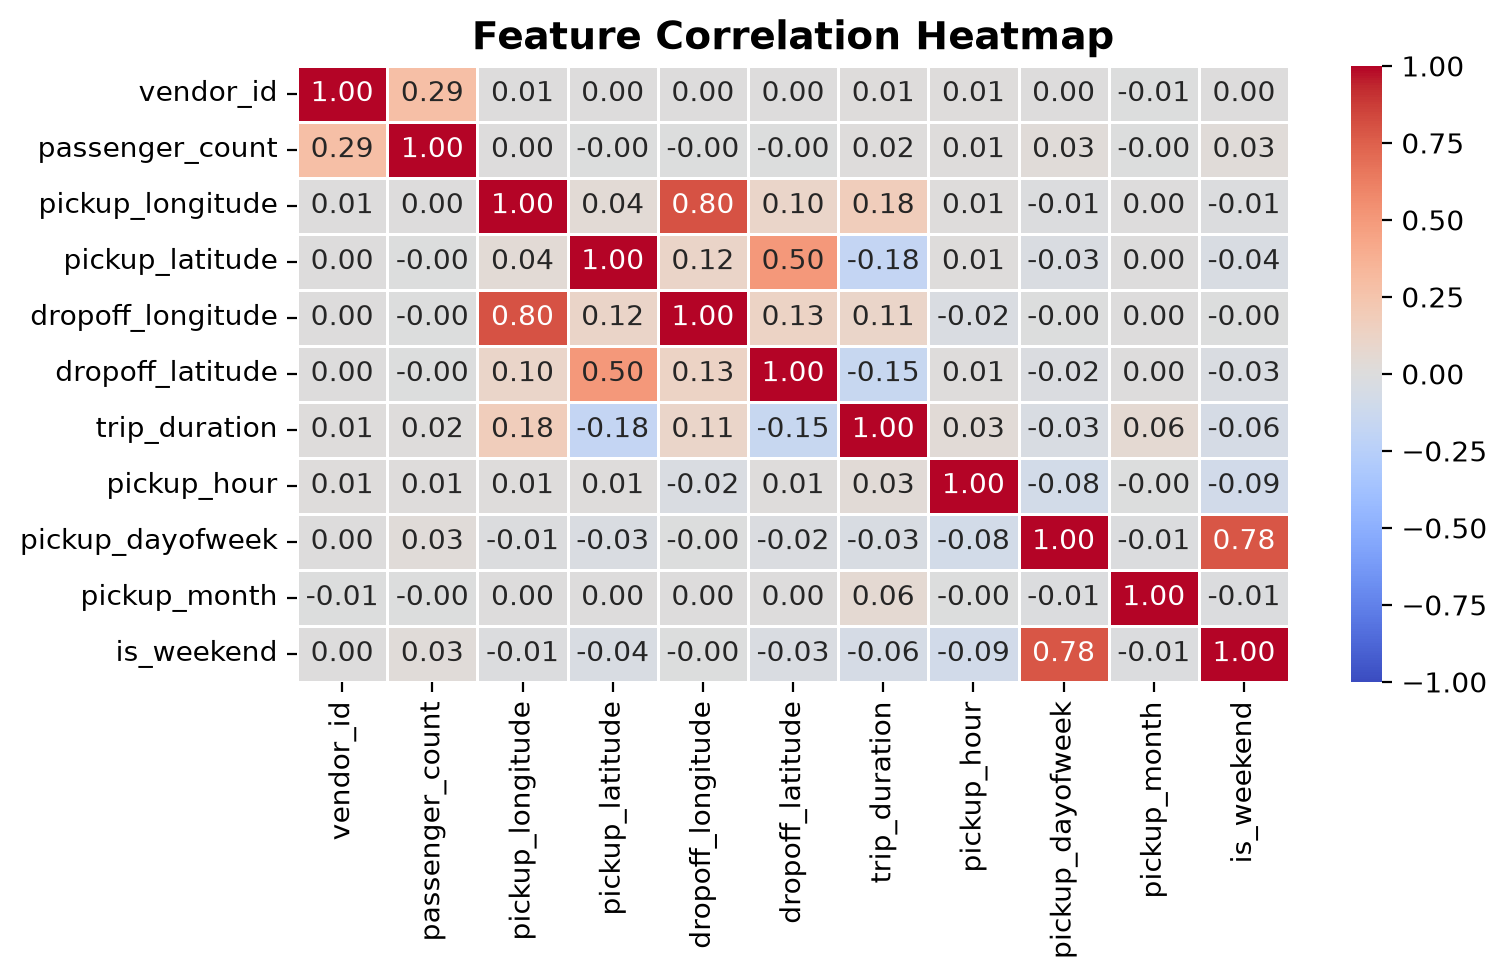

In [26]:

plt.figure(figsize=(8, 4))

# Calculate Pearson correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot styled correlation heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,              # Display numerical values in cells
    fmt=".2f",               # Format to 2 decimal places
    cmap="coolwarm",         # Blue = negative correlation, Red = positive correlation
    vmin=-1, vmax=1, 
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.show()

In [27]:

from math import radians, sin, cos, sqrt, asin

# Set up seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 12

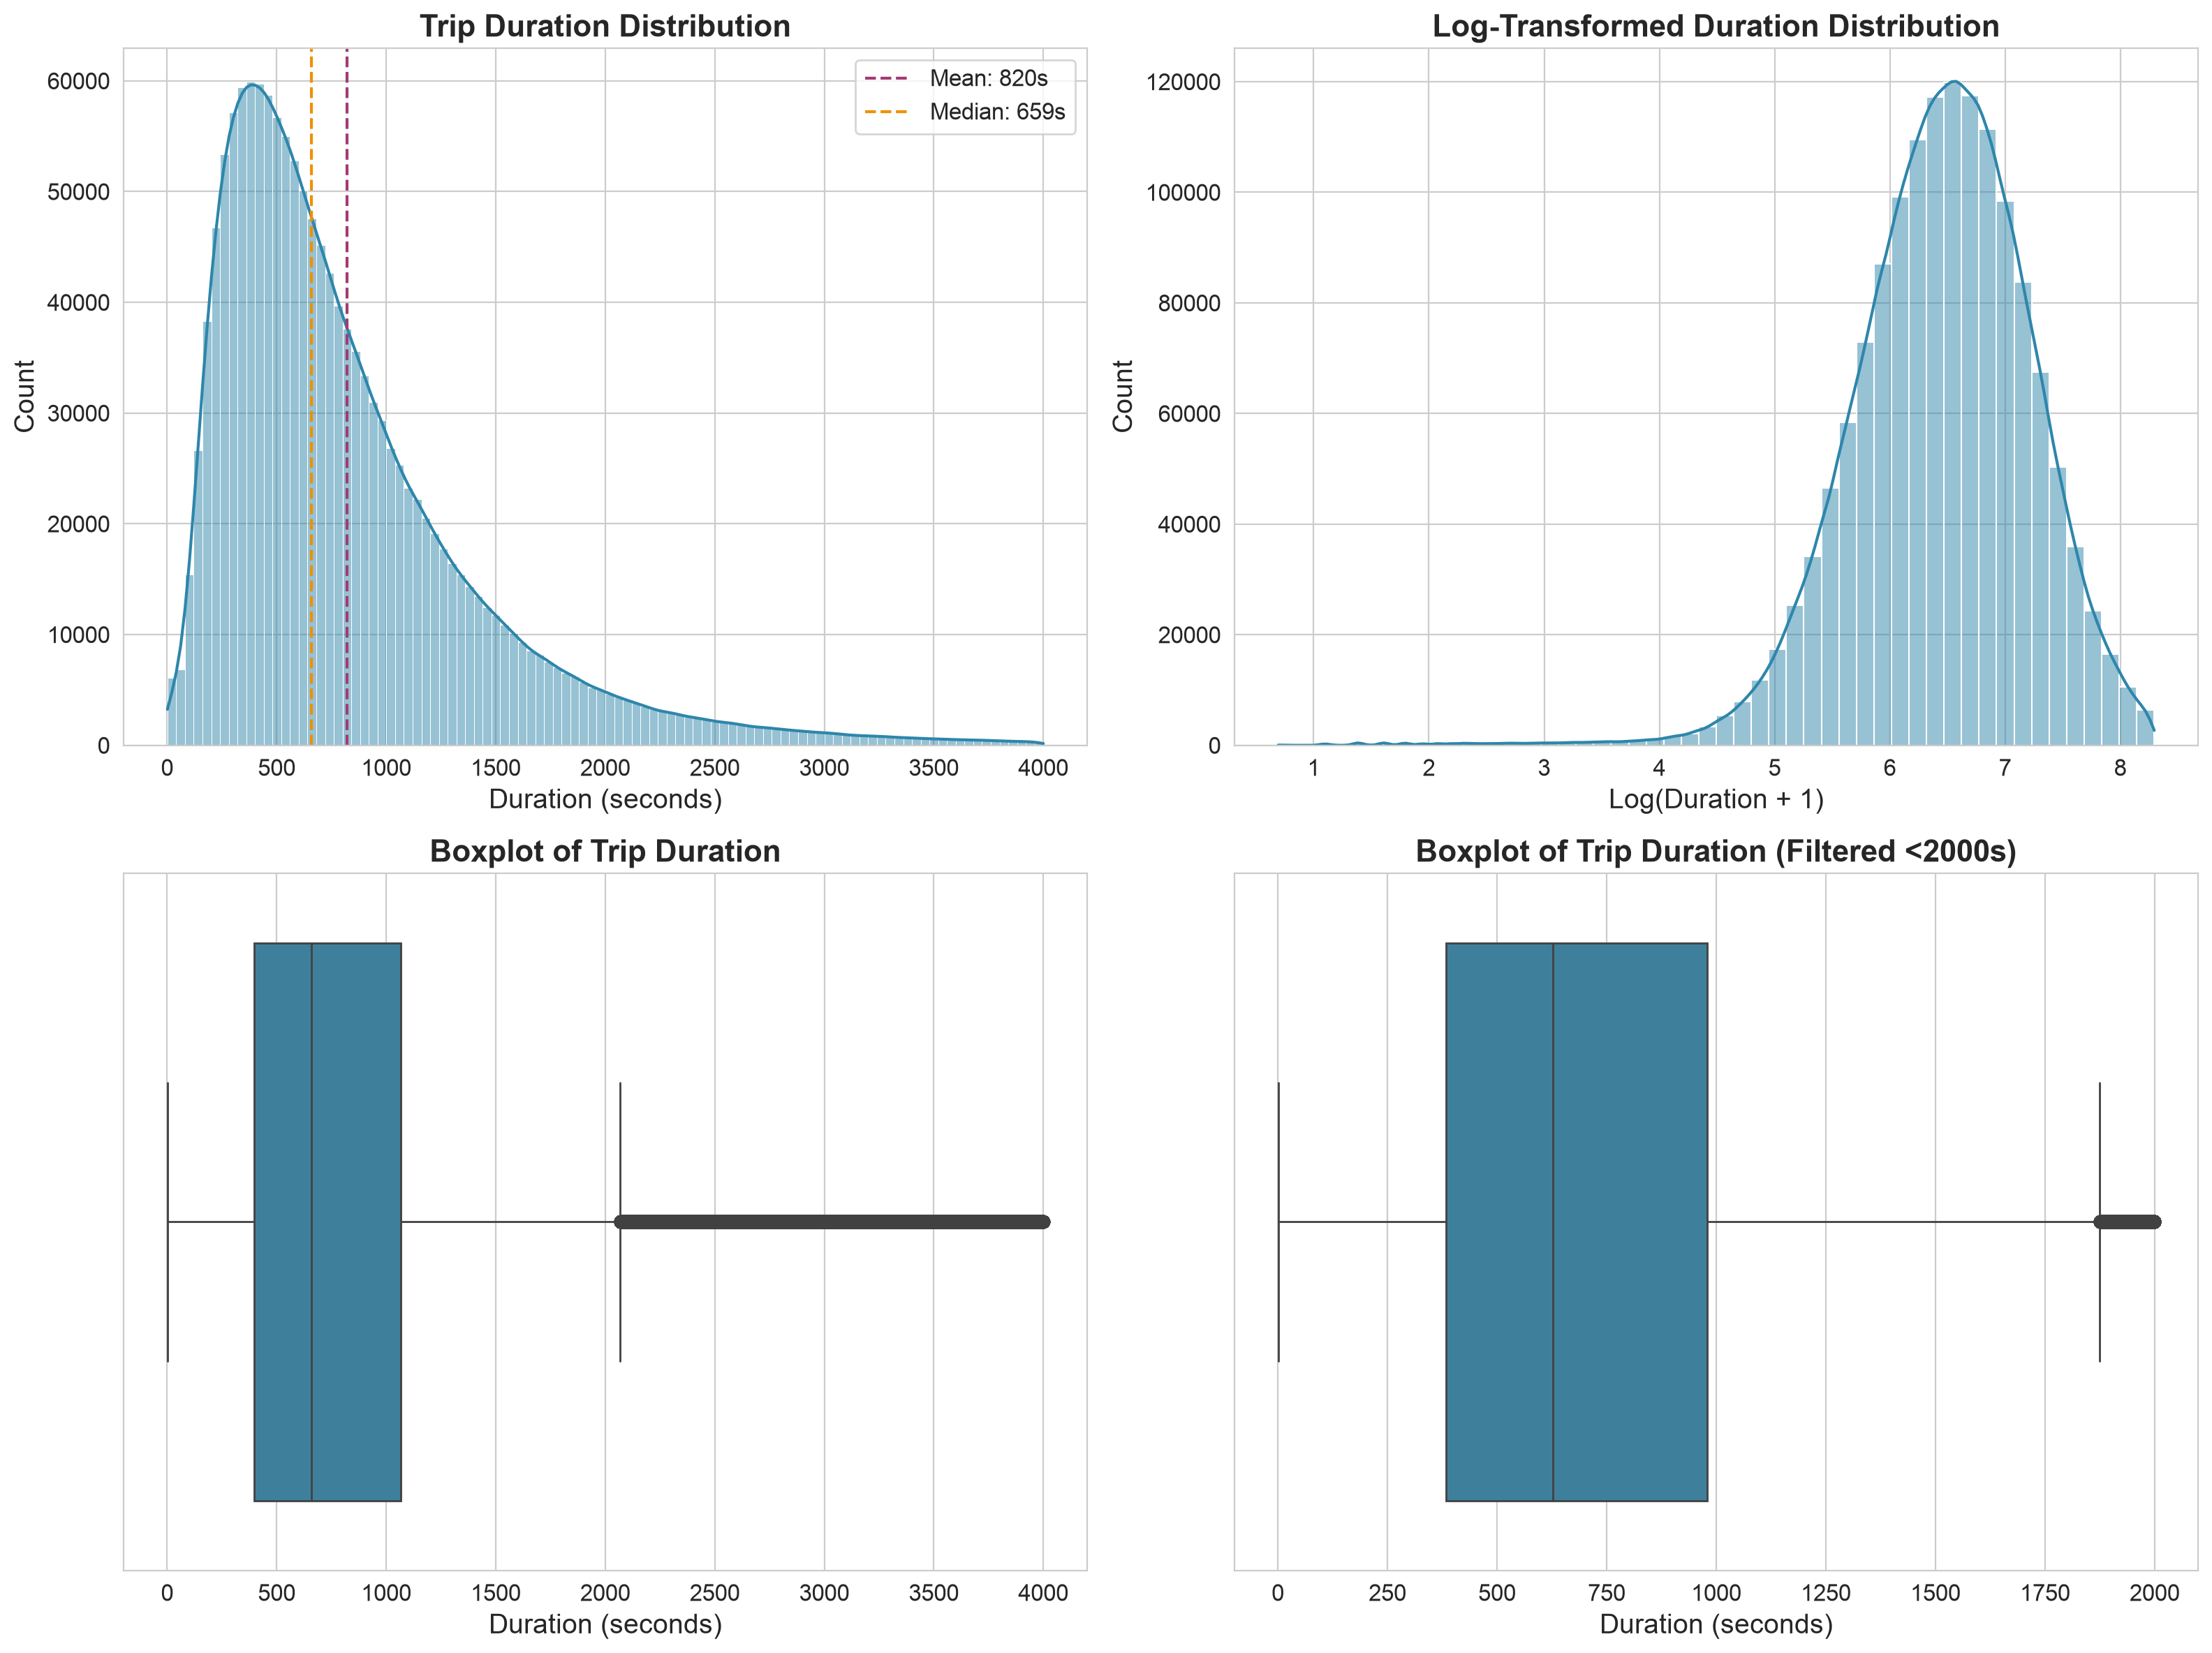

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Raw distribution
sns.histplot(df['trip_duration'], bins=100, kde=True, ax=axes[0, 0], color='#2E86AB')
axes[0, 0].axvline(df['trip_duration'].mean(), color='#A23B72', linestyle='--', label=f'Mean: {df["trip_duration"].mean():.0f}s')
axes[0, 0].axvline(df['trip_duration'].median(), color='#F18F01', linestyle='--', label=f'Median: {df["trip_duration"].median():.0f}s')
axes[0, 0].set_title('Trip Duration Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Duration (seconds)')
axes[0, 0].legend()

# Log-transformed distribution
sns.histplot(np.log1p(df['trip_duration']), bins=50, kde=True, ax=axes[0, 1], color='#2E86AB')
axes[0, 1].set_title('Log-Transformed Duration Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Log(Duration + 1)')

# Boxplot with outliers
sns.boxplot(x=df['trip_duration'], ax=axes[1, 0], color='#2E86AB')
axes[1, 0].set_title('Boxplot of Trip Duration', fontweight='bold')
axes[1, 0].set_xlabel('Duration (seconds)')

# Boxplot without outliers (zoomed)
filtered_duration = df['trip_duration'][df['trip_duration'] < 2000]
sns.boxplot(x=filtered_duration, ax=axes[1, 1], color='#2E86AB')
axes[1, 1].set_title('Boxplot of Trip Duration (Filtered <2000s)', fontweight='bold')
axes[1, 1].set_xlabel('Duration (seconds)')

plt.tight_layout()
plt.show()

In [29]:
df = df[df['trip_duration'] > 100]

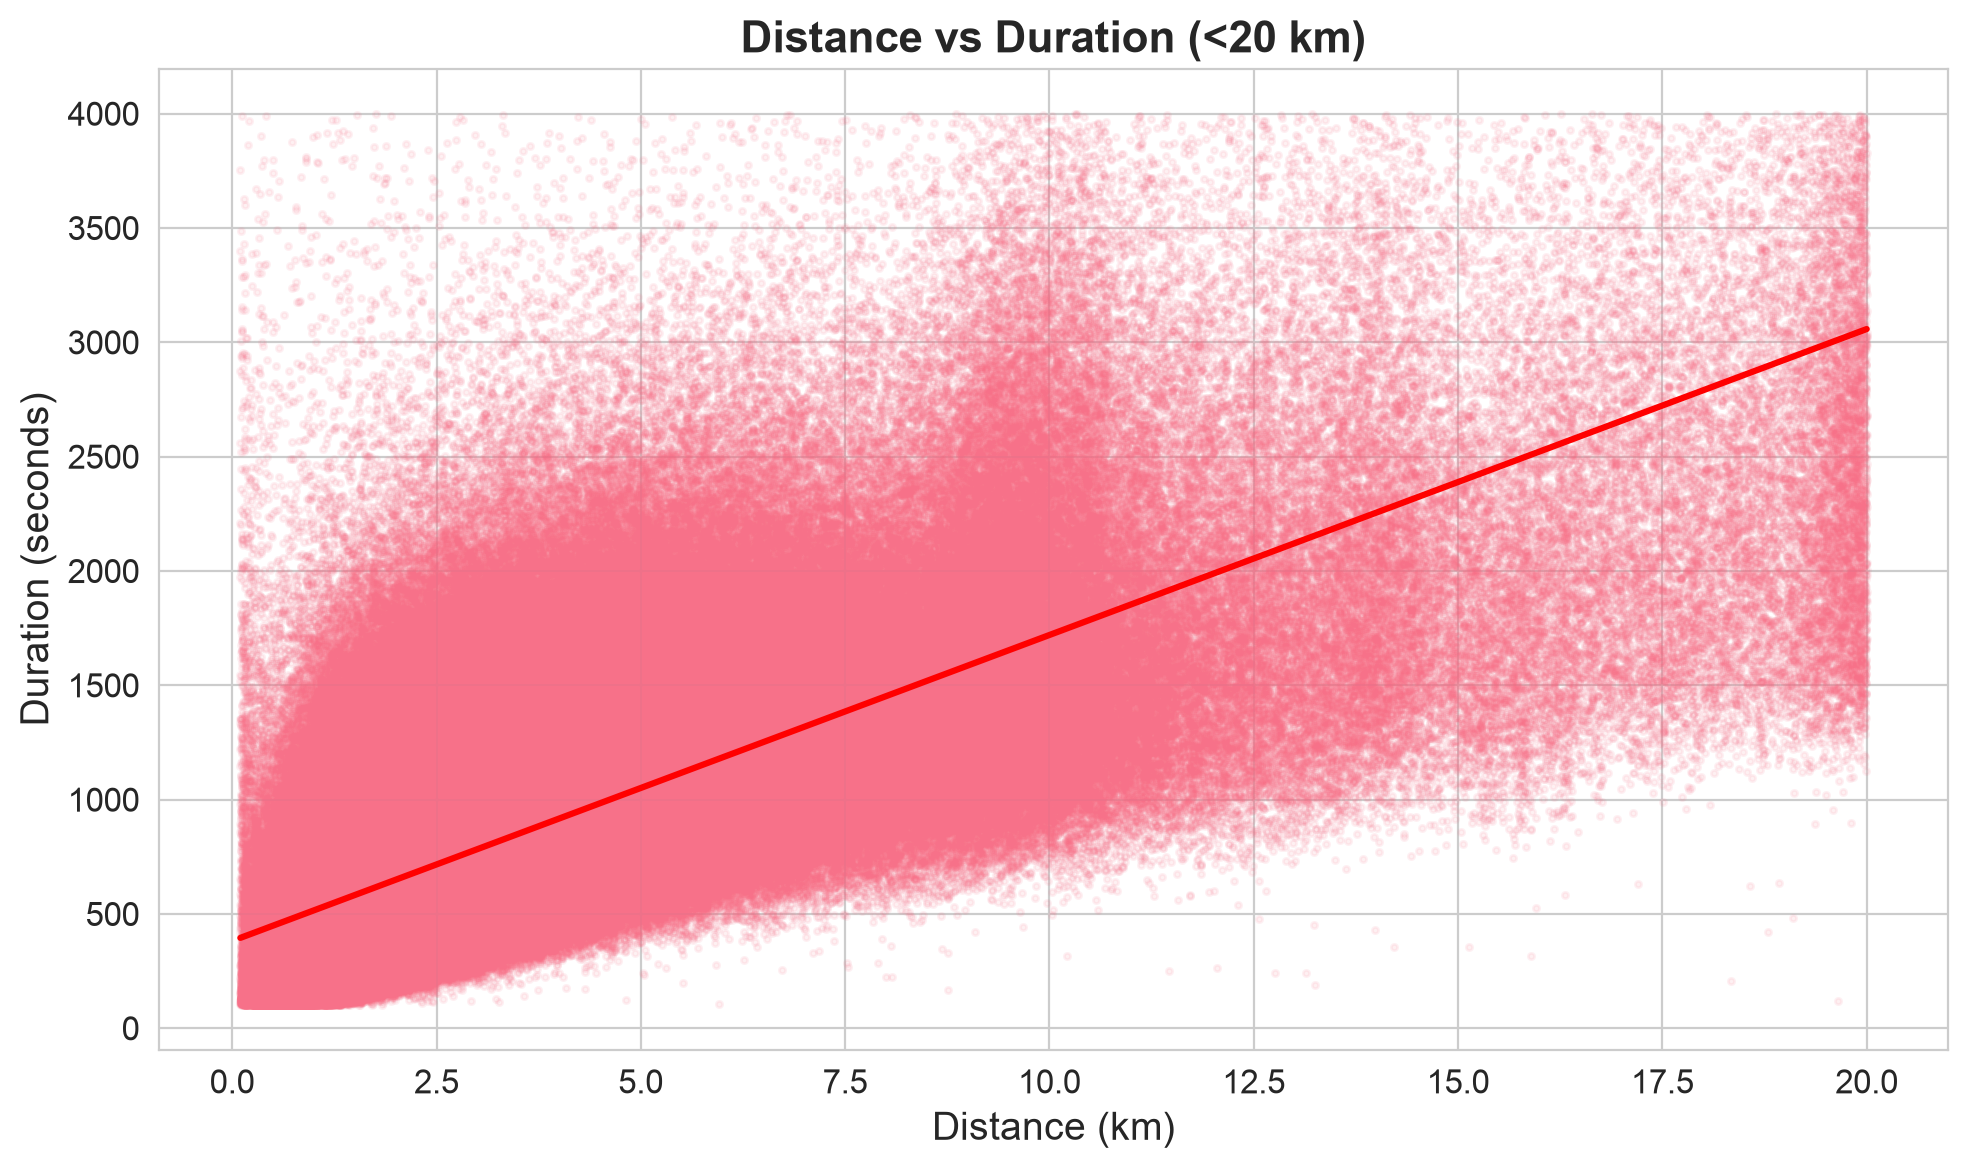

In [30]:
from geopy.distance import geodesic

# Distance Feature
df["distance_km"] = df.apply(
    lambda row: geodesic(
        (row["pickup_latitude"], row["pickup_longitude"]),
        (row["dropoff_latitude"], row["dropoff_longitude"])
    ).km,
    axis=1
)

# Filter for visualization
df_clean = df[
    (df["distance_km"] > 0.1) &
    (df["trip_duration"] < 7200)
]

filtered = df_clean[df_clean["distance_km"] < 20]

# Plot
plt.figure(figsize=(10, 6))

sns.regplot(
    x="distance_km",
    y="trip_duration",
    data=filtered,
    scatter_kws={"alpha": 0.1, "s": 5},
    line_kws={"color": "red"}
)

plt.title("Distance vs Duration (<20 km)", fontweight="bold")
plt.xlabel("Distance (km)")
plt.ylabel("Duration (seconds)")

plt.tight_layout()
plt.show()

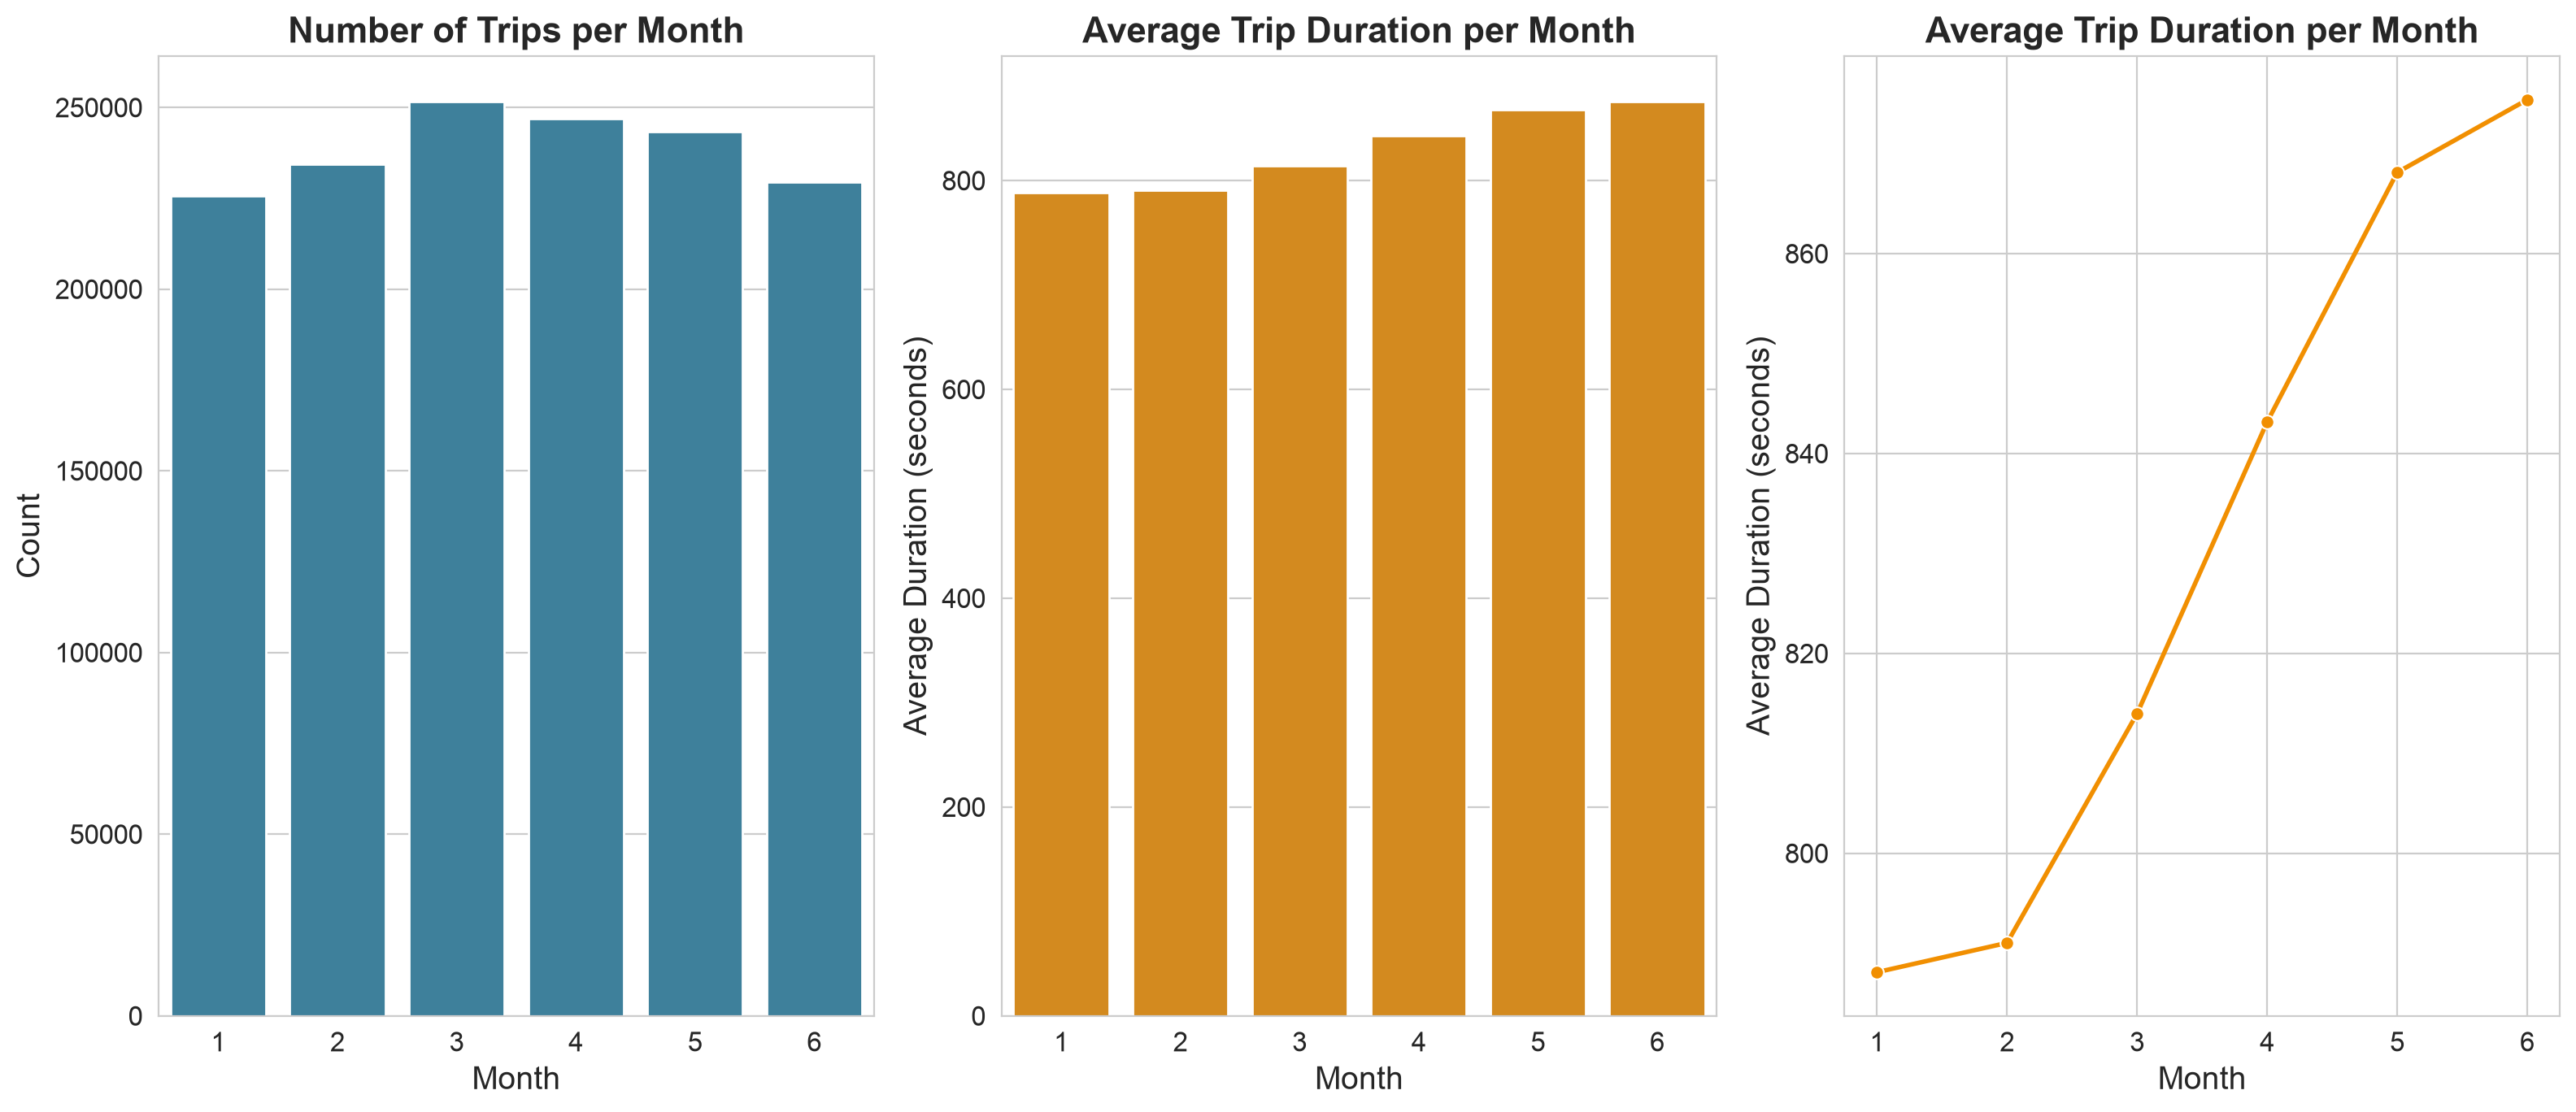

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 7))

# --- Plot 1: Count of Trips per Month ---

sns.barplot(data=df, x='pickup_month', y='trip_duration', 
            ax=axes[0], estimator='size', color='#2E86AB', errorbar=None)
axes[0].set_title('Number of Trips per Month', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')

# --- Plot 2: Average Duration per Month ---
sns.barplot(data=df, x='pickup_month', y='trip_duration', 
            ax=axes[1], estimator='mean', color='#F18F01', errorbar=None)
axes[1].set_title('Average Trip Duration per Month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Duration (seconds)')

# --- Plot 3: Average Duration per Month But Lineplot ---
monthly_mean = df.groupby('pickup_month')['trip_duration'].mean().reset_index()
sns.lineplot(data=monthly_mean, x='pickup_month', y='trip_duration', 
             ax=axes[2], marker='o', color='#F18F01', linewidth=2)
axes[2].set_title('Average Trip Duration per Month', fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Average Duration (seconds)')

plt.tight_layout()
plt.show()

> there is an upward trend, hence there is a pattern. So we should leave it

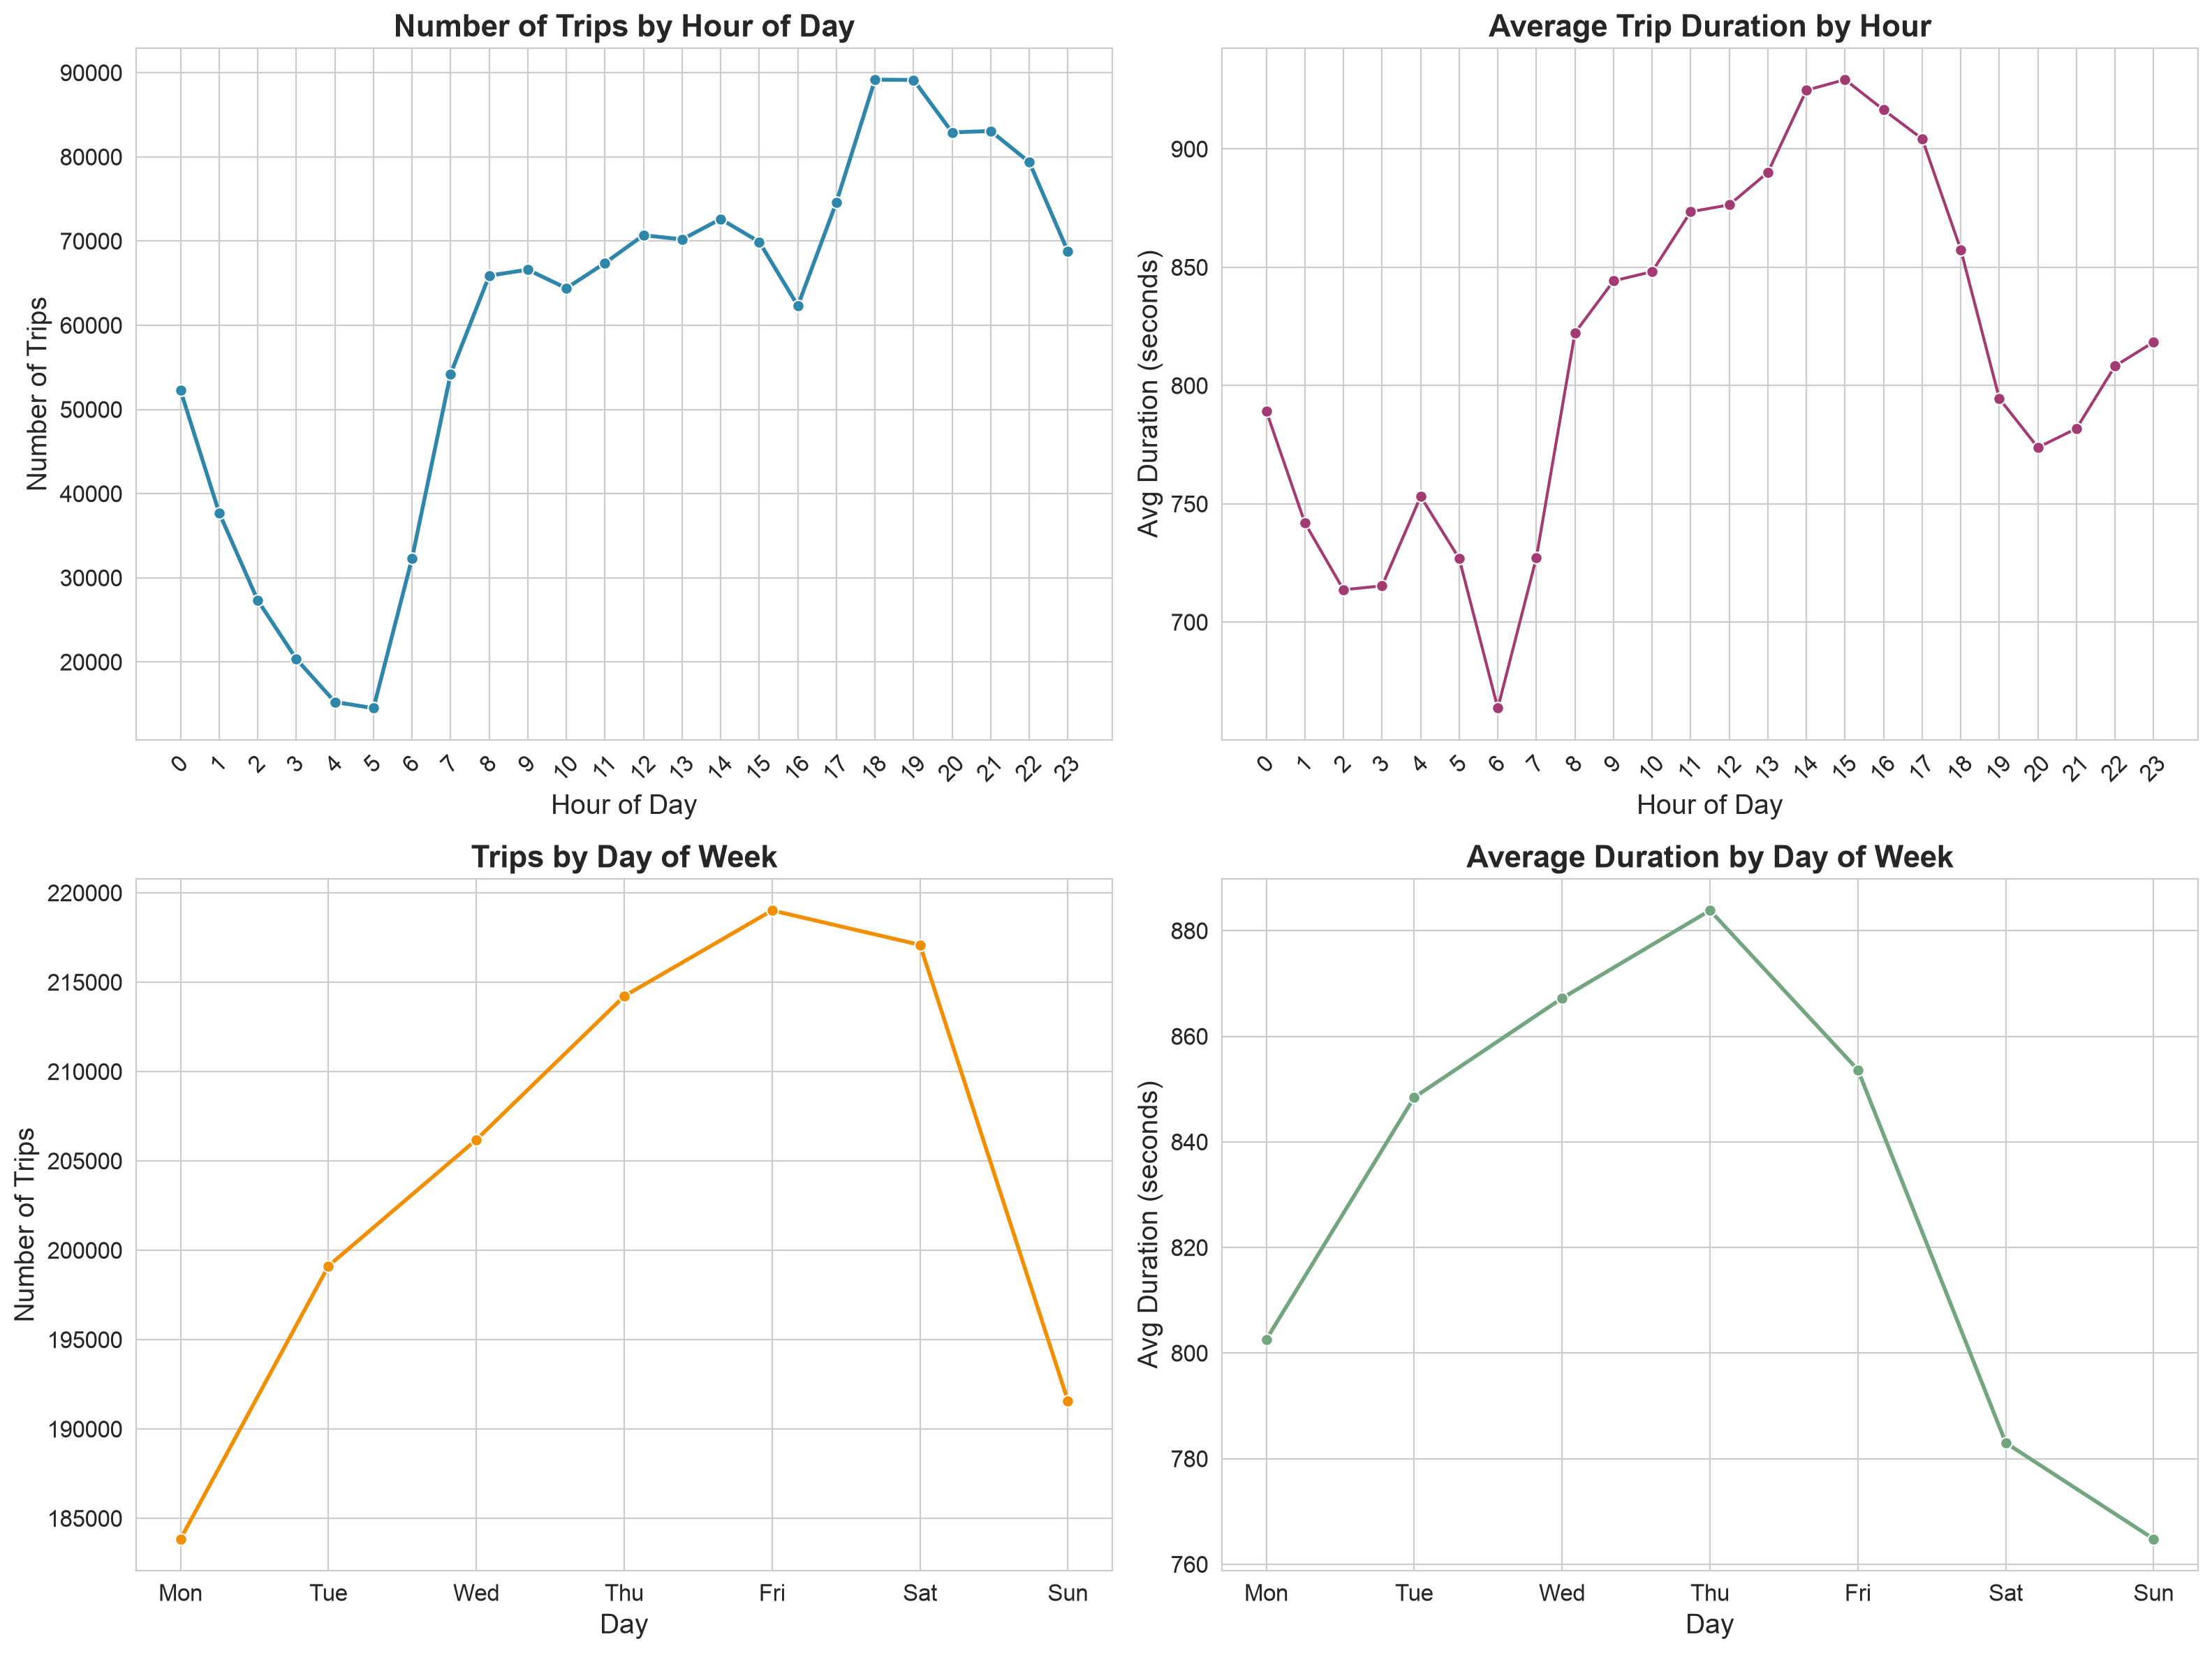

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Trip count by hour
hourly_counts = df.groupby('pickup_hour').size()
sns.lineplot(x=hourly_counts.index, y=hourly_counts.values, ax=axes[0, 0], color='#2E86AB', marker='o', linewidth=2)  
axes[0, 0].set_title('Number of Trips by Hour of Day', fontweight='bold')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Number of Trips')
# FIX: Show all 24 hours for this plot too
axes[0, 0].set_xticks(range(0, 24))
axes[0, 0].set_xticklabels(range(0, 24), rotation=45)


# 2. Average duration by hour 
hourly_duration = df.groupby('pickup_hour')['trip_duration'].mean()
sns.lineplot(x=hourly_duration.index, y=hourly_duration.values, ax=axes[0, 1], marker='o', color='#A23B72')

axes[0, 1].set_xticks(range(0, 24))  
axes[0, 1].set_xticklabels(range(0, 24), rotation=45)
axes[0, 1].set_title('Average Trip Duration by Hour', fontweight='bold')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Avg Duration (seconds)')


# 3. Trip count by day of week
day_counts = df.groupby('pickup_dayofweek').size()
sns.lineplot(x=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], 
            y=day_counts.values, ax=axes[1, 0], color='#F18F01', marker='o', linewidth=2)  
axes[1, 0].set_title('Trips by Day of Week', fontweight='bold')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Number of Trips')


# 4. Average duration by day of week
day_duration = df.groupby('pickup_dayofweek')['trip_duration'].mean()
sns.lineplot(x=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], 
            y=day_duration.values, ax=axes[1, 1], color='#73A580', marker='o', linewidth=2) 
axes[1, 1].set_title('Average Duration by Day of Week', fontweight='bold')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_ylabel('Avg Duration (seconds)')

plt.tight_layout()
plt.show()

> in the early morning, there isnt much trips.

> there isn't much trips on weekend.


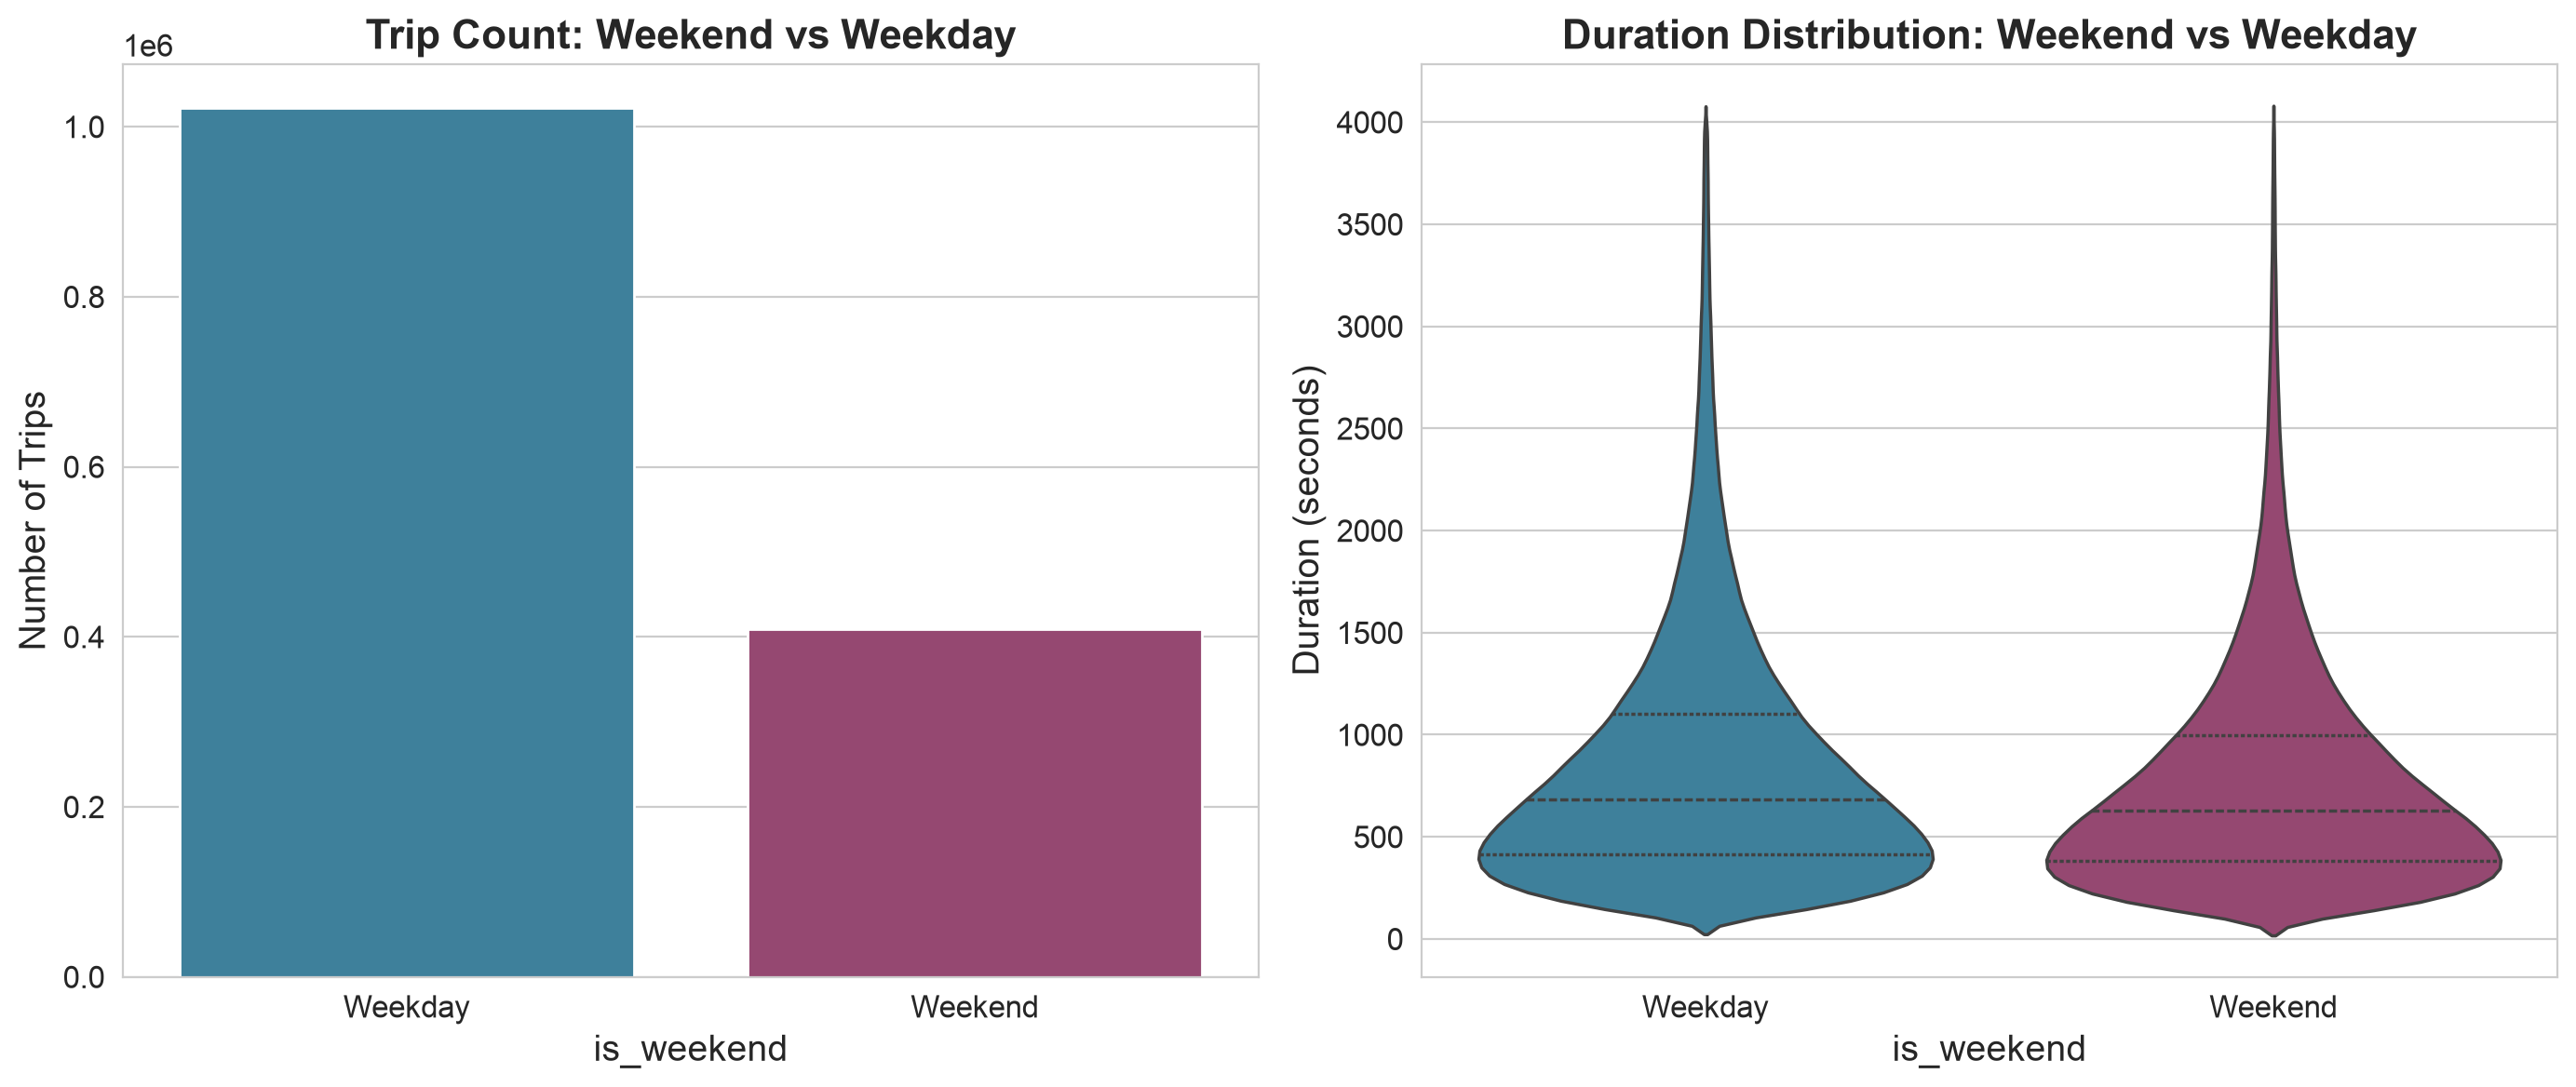


Duration Statistics:
                count        mean         std    min    25%    50%     75%  \
is_weekend                                                                   
0           1022394.0  852.513768  618.954019  101.0  415.0  684.0  1104.0   
1            408667.0  774.467221  554.048855  101.0  384.0  627.0   999.0   

               max  
is_weekend          
0           4000.0  
1           3997.0  


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
sns.countplot(
    x="is_weekend",
    hue="is_weekend",
    data=df,
    ax=axes[0],
    palette=["#2E86AB", "#A23B72"],
    legend=False
)

axes[0].set_title("Trip Count: Weekend vs Weekday", fontweight="bold")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Weekday", "Weekend"])
axes[0].set_ylabel("Number of Trips")


# Violin plot
sns.violinplot(
    x="is_weekend",
    y="trip_duration",
    hue="is_weekend",
    data=df,
    ax=axes[1],
    palette=["#2E86AB", "#A23B72"],
    inner="quartile",
    legend=False
)

axes[1].set_title(
    "Duration Distribution: Weekend vs Weekday",
    fontweight="bold"
)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Weekday", "Weekend"])
axes[1].set_ylabel("Duration (seconds)")

plt.tight_layout()
plt.show()


# Statistical summary
print("\nDuration Statistics:")
print(df.groupby("is_weekend")["trip_duration"].describe())

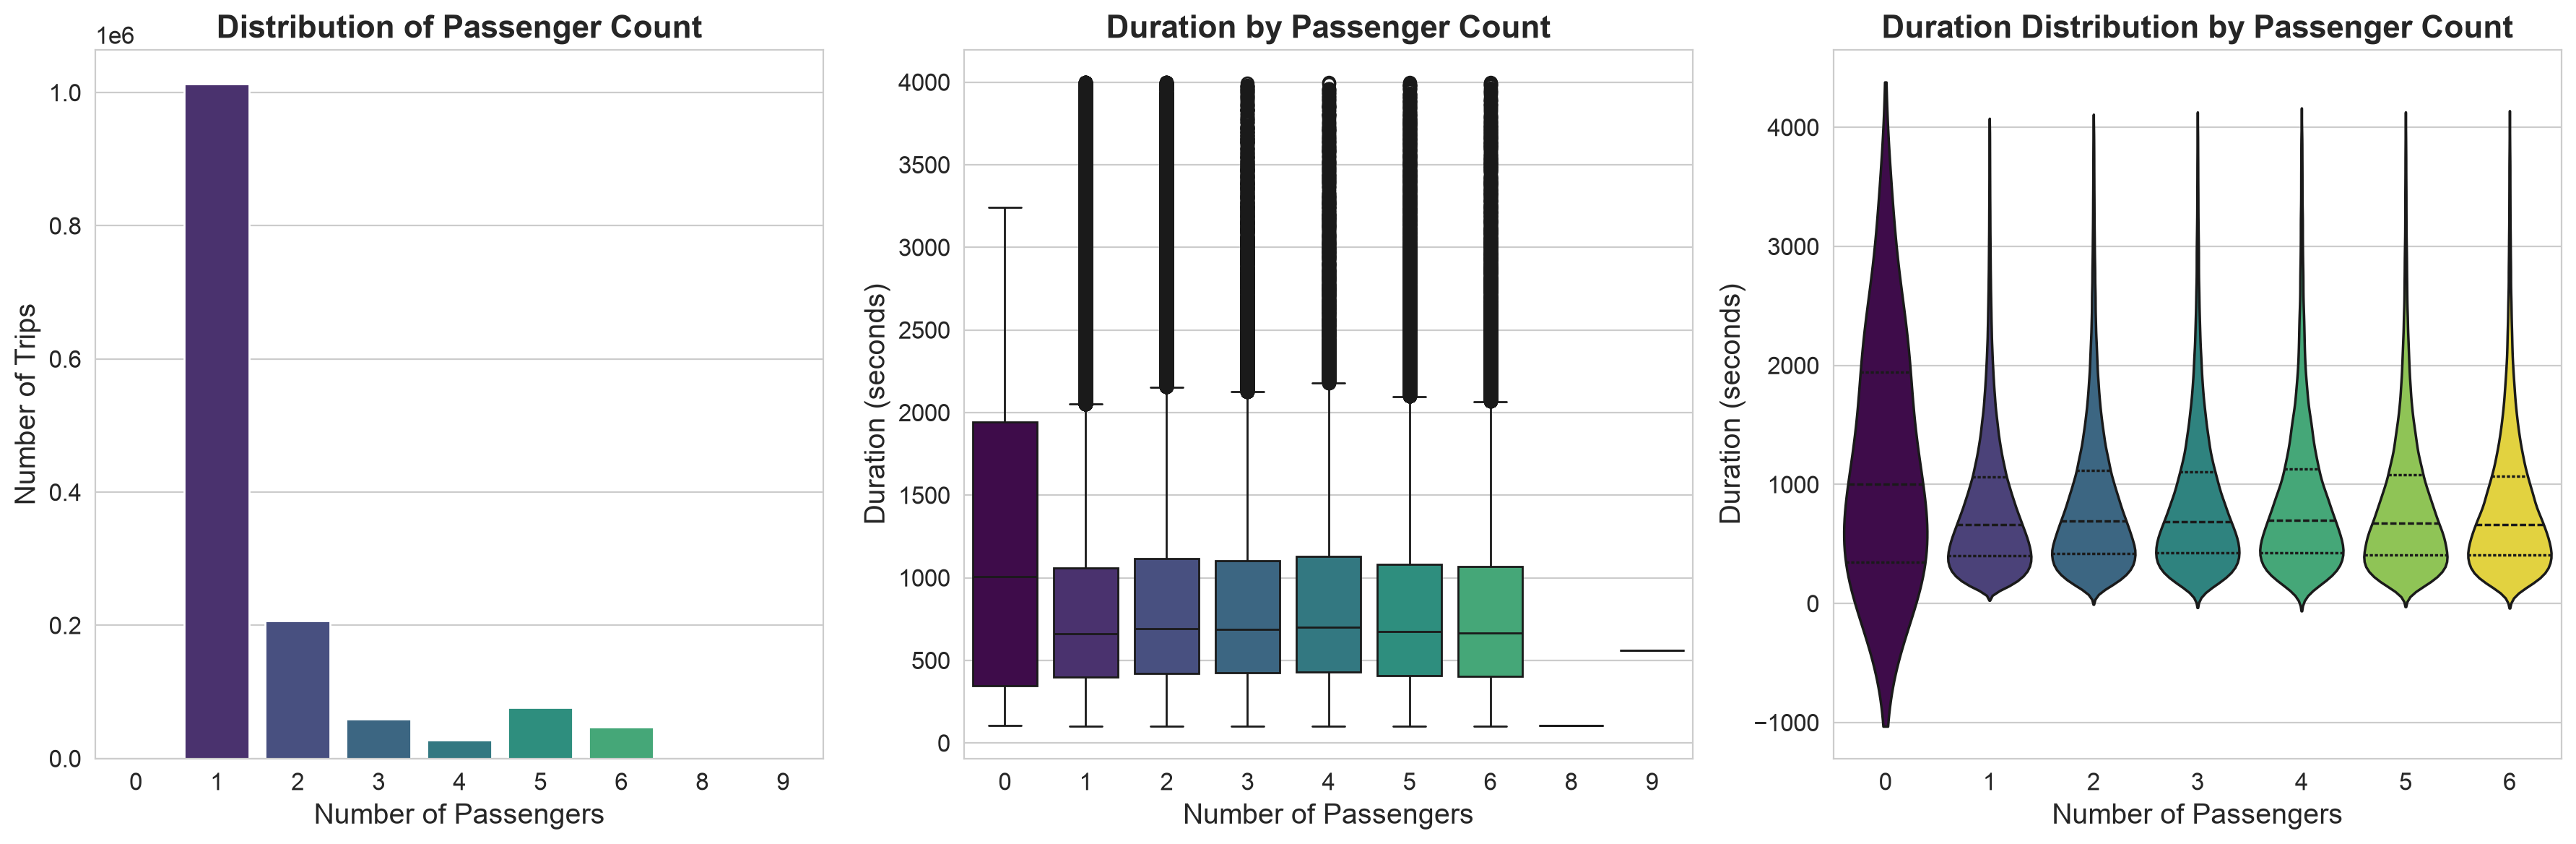

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Count plot
sns.countplot(
    x="passenger_count",
    hue="passenger_count",
    data=df,
    ax=axes[0],
    palette="viridis",
    legend=False
)

axes[0].set_title("Distribution of Passenger Count", fontweight="bold")
axes[0].set_xlabel("Number of Passengers")
axes[0].set_ylabel("Number of Trips")


# Box plot
sns.boxplot(
    x="passenger_count",
    y="trip_duration",
    hue="passenger_count",
    data=df,
    ax=axes[1],
    palette="viridis",
    legend=False
)

axes[1].set_title("Duration by Passenger Count", fontweight="bold")
axes[1].set_xlabel("Number of Passengers")
axes[1].set_ylabel("Duration (seconds)")


# Violin plot
filtered_pass = df[df["passenger_count"] <= 6]

sns.violinplot(
    x="passenger_count",
    y="trip_duration",
    hue="passenger_count",
    data=filtered_pass,
    ax=axes[2],
    palette="viridis",
    inner="quartile",
    legend=False
)

axes[2].set_title(
    "Duration Distribution by Passenger Count",
    fontweight="bold"
)
axes[2].set_xlabel("Number of Passengers")
axes[2].set_ylabel("Duration (seconds)")

plt.tight_layout()
plt.show()

In [35]:
df = df.drop(columns=['passenger_count'])

> box plots are similar but the number of passengers ,differ, so the features is almost useless. we may drop it.

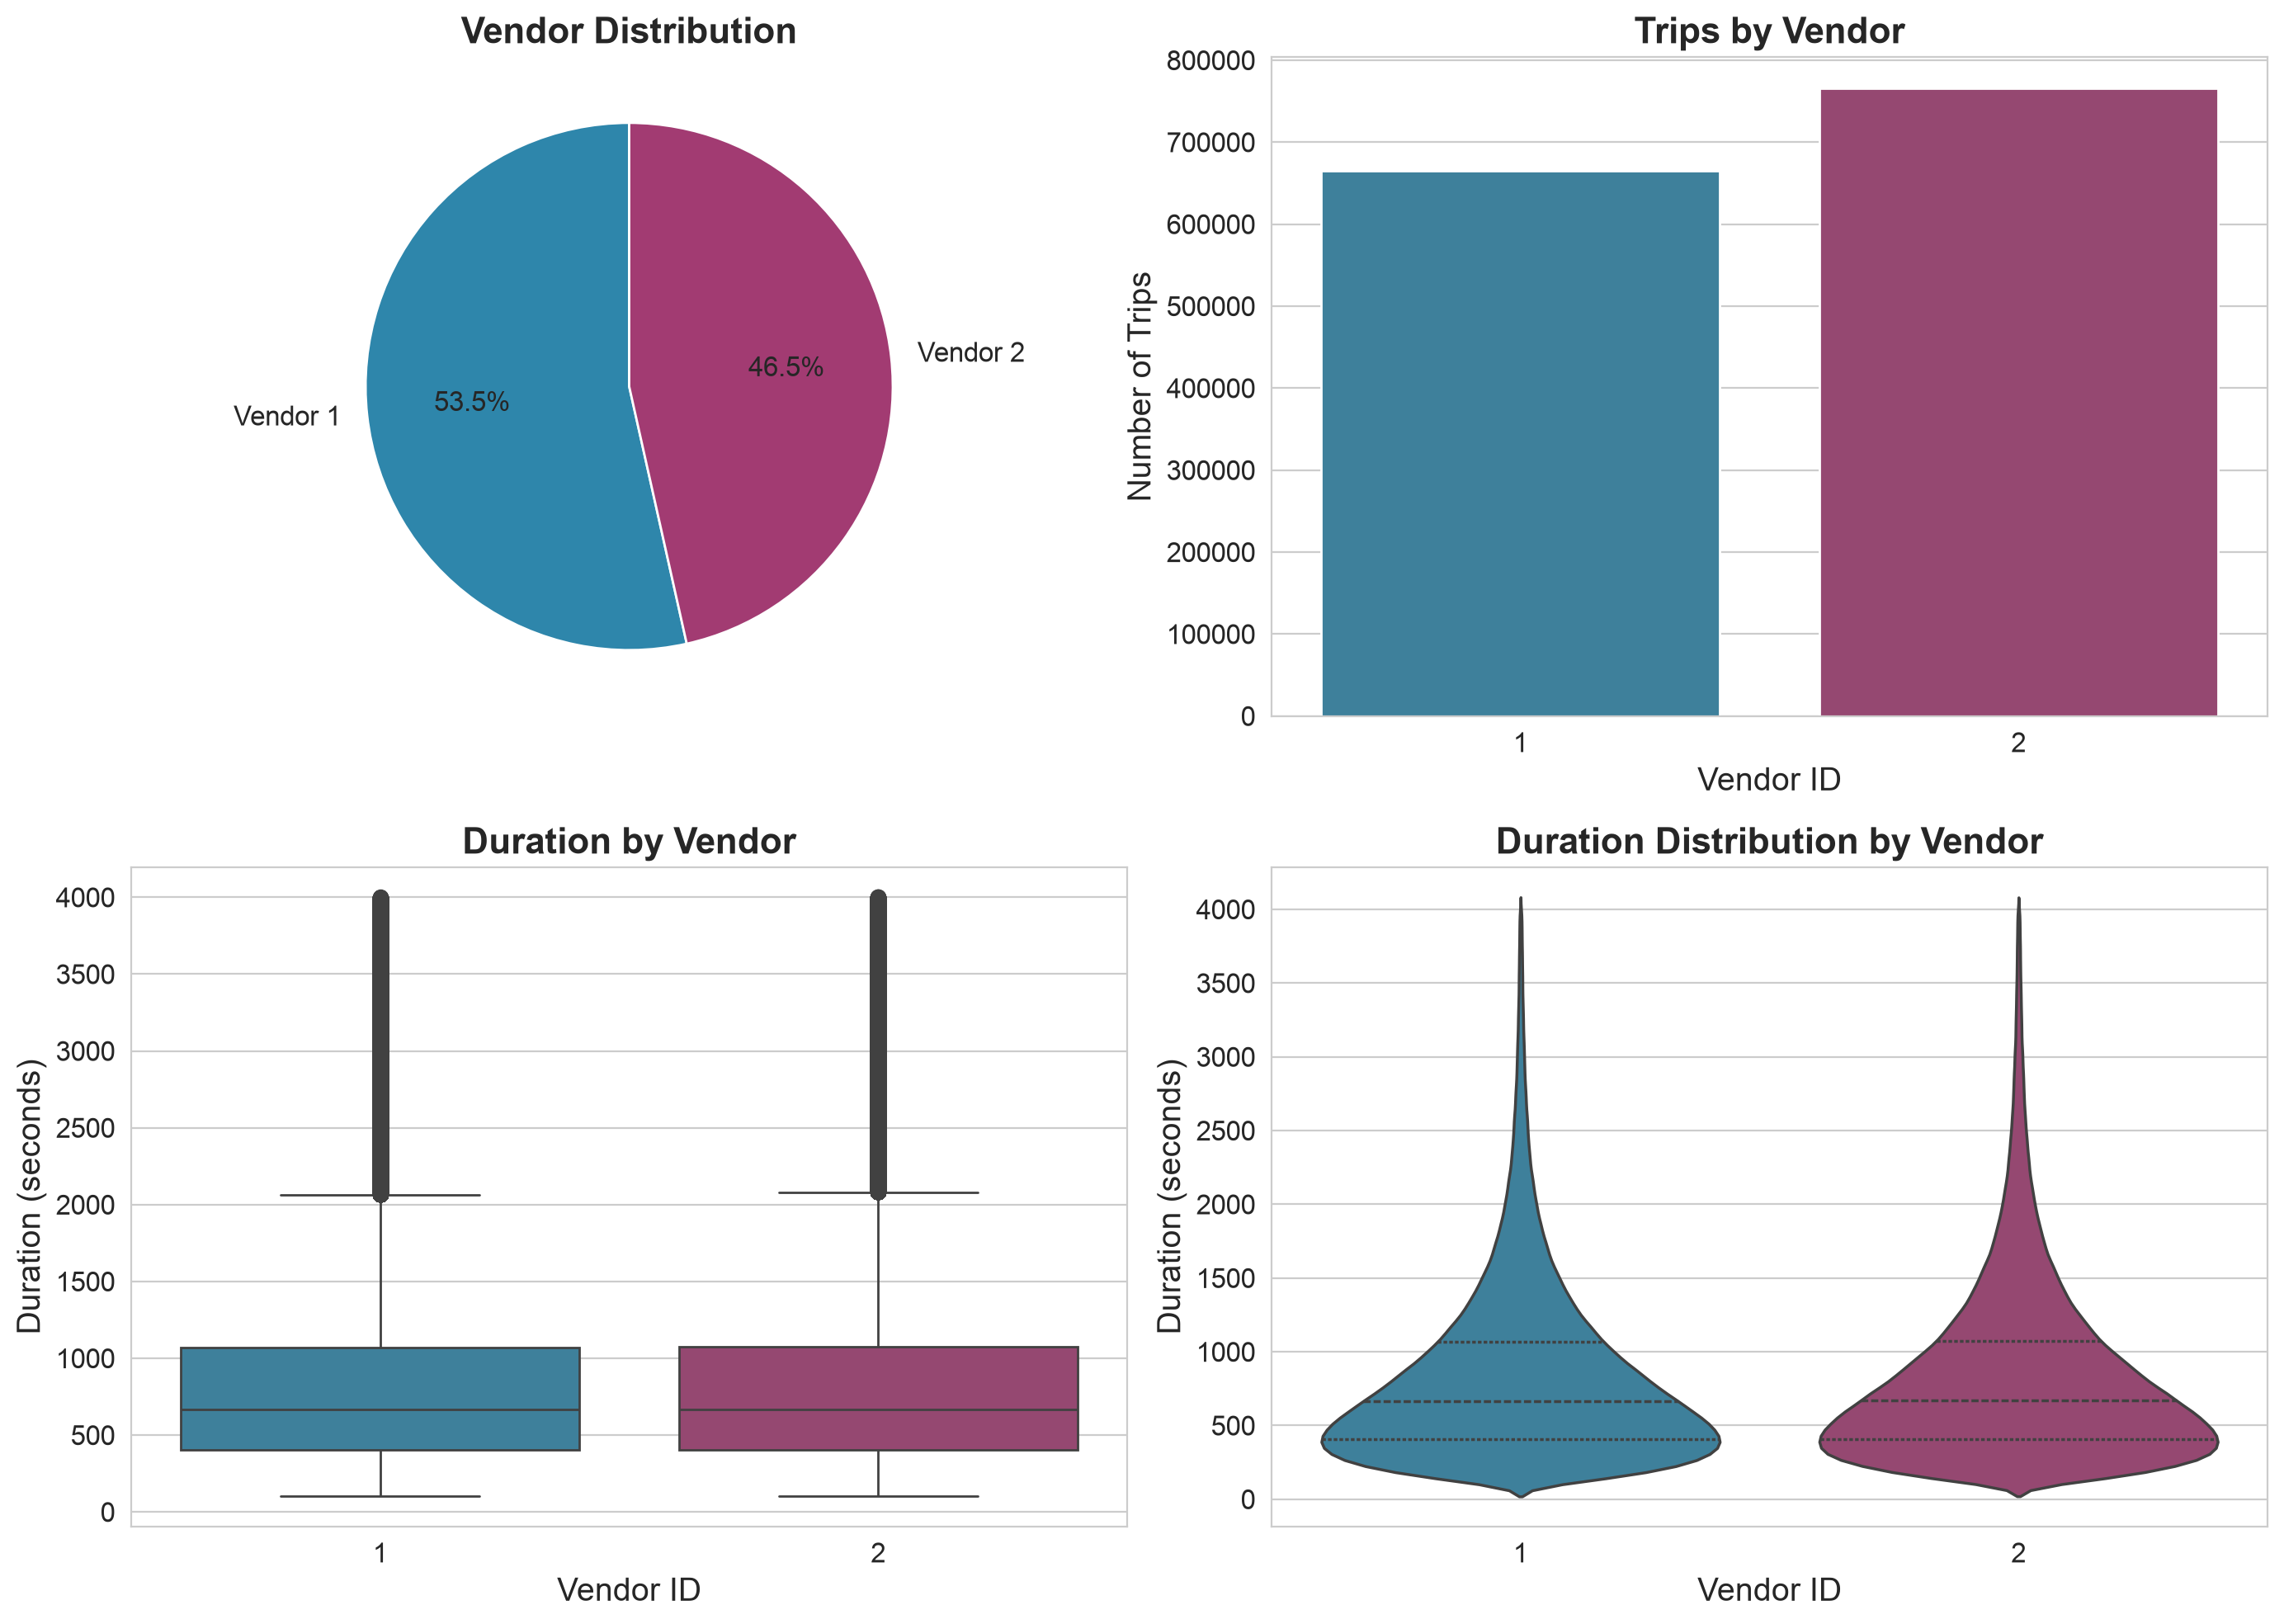


Vendor Statistics:
              count        mean         std    min    25%    50%     75%  \
vendor_id                                                                  
1          665392.0  826.511503  597.274480  101.0  405.0  665.0  1069.0   
2          765669.0  833.454162  606.368581  101.0  406.0  669.0  1076.0   

              max  
vendor_id          
1          4000.0  
2          4000.0  


In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pie chart
vendor_counts = df["vendor_id"].value_counts()

colors = ["#2E86AB", "#A23B72"]

axes[0, 0].pie(
    vendor_counts.values,
    labels=["Vendor 1", "Vendor 2"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90
)

axes[0, 0].set_title(
    "Vendor Distribution",
    fontweight="bold"
)


# Count plot
sns.countplot(
    x="vendor_id",
    hue="vendor_id",
    data=df,
    ax=axes[0, 1],
    palette=colors,
    legend=False
)

axes[0, 1].set_title(
    "Trips by Vendor",
    fontweight="bold"
)

axes[0, 1].set_xlabel("Vendor ID")
axes[0, 1].set_ylabel("Number of Trips")


# Box plot
sns.boxplot(
    x="vendor_id",
    y="trip_duration",
    hue="vendor_id",
    data=df,
    ax=axes[1, 0],
    palette=colors,
    legend=False
)

axes[1, 0].set_title(
    "Duration by Vendor",
    fontweight="bold"
)

axes[1, 0].set_xlabel("Vendor ID")
axes[1, 0].set_ylabel("Duration (seconds)")


# Violin plot
sns.violinplot(
    x="vendor_id",
    y="trip_duration",
    hue="vendor_id",
    data=df,
    ax=axes[1, 1],
    palette=colors,
    inner="quartile",
    legend=False
)

axes[1, 1].set_title(
    "Duration Distribution by Vendor",
    fontweight="bold"
)

axes[1, 1].set_xlabel("Vendor ID")
axes[1, 1].set_ylabel("Duration (seconds)")

plt.tight_layout()
plt.show()


# Statistical comparison
print("\nVendor Statistics:")
print(
    df.groupby("vendor_id")["trip_duration"].describe()
)

In [37]:
print(df.groupby('vendor_id')['trip_duration'].mean())

vendor_id
1    826.511503
2    833.454162
Name: trip_duration, dtype: float64


it may be dropped as well

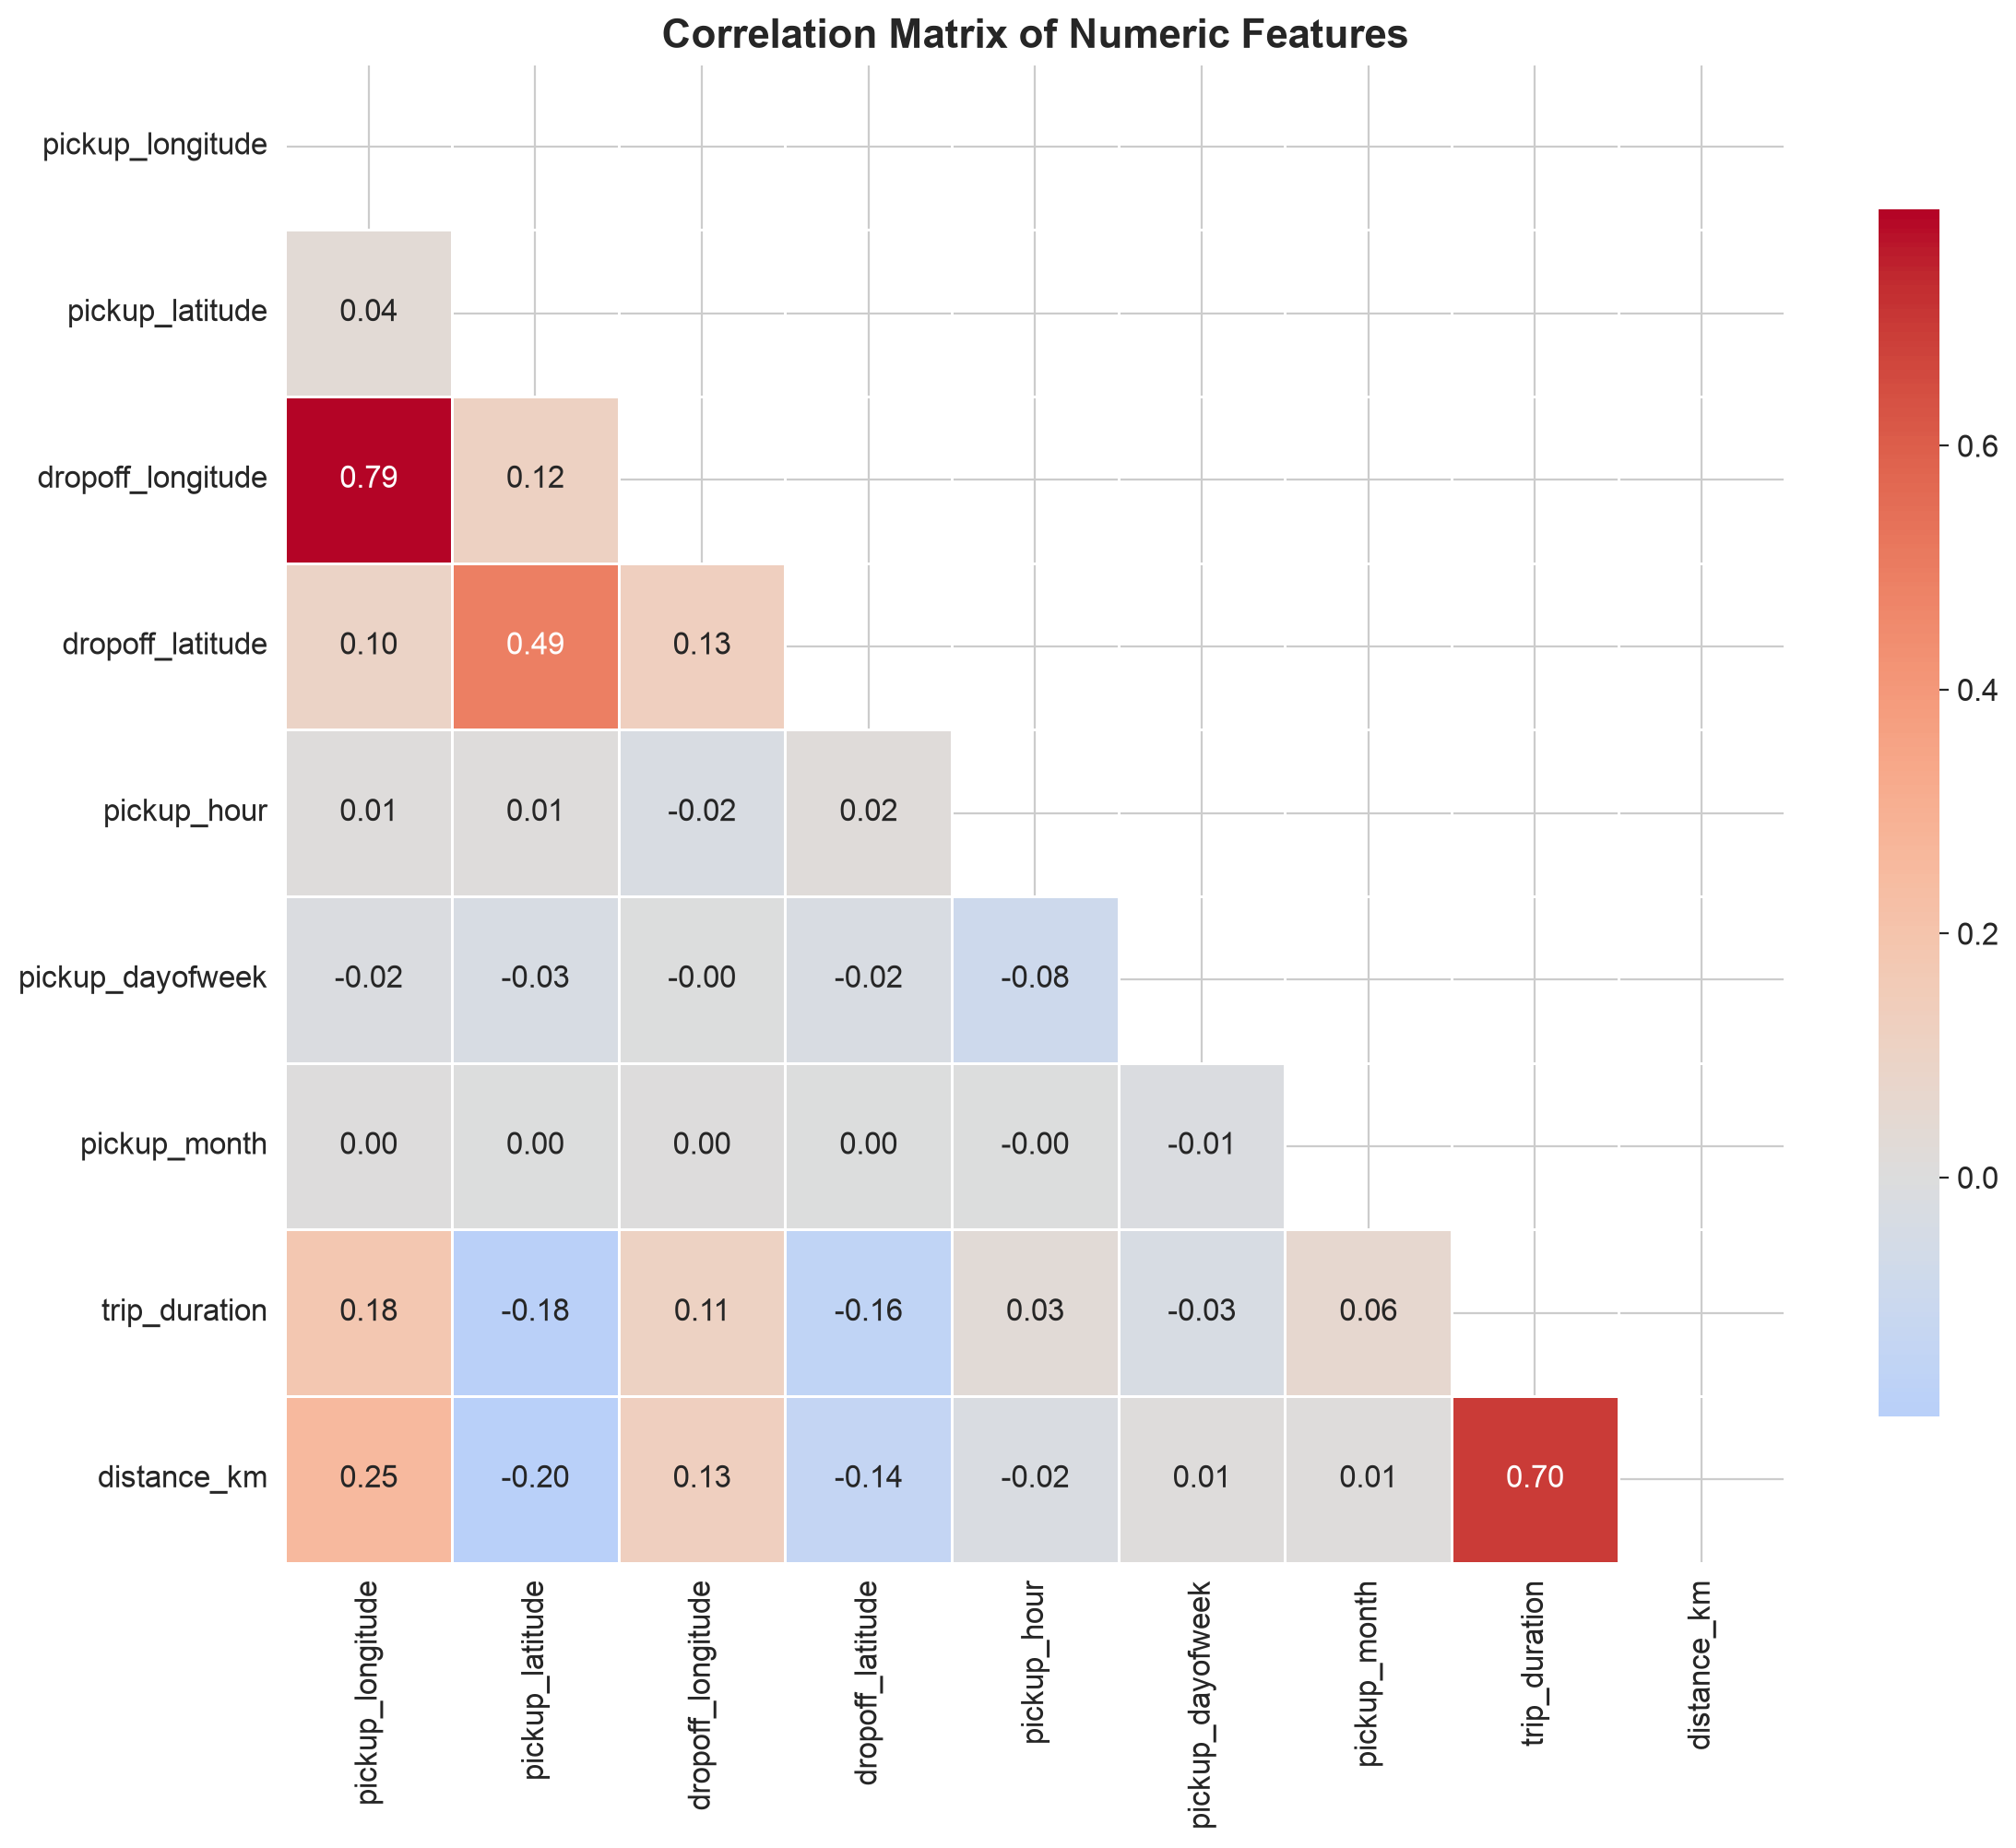


Correlations with trip_duration:
trip_duration        1.000000
distance_km          0.695236
pickup_longitude     0.181656
dropoff_longitude    0.110897
pickup_month         0.055862
pickup_hour          0.030767
pickup_dayofweek    -0.031241
dropoff_latitude    -0.157612
pickup_latitude     -0.184390
Name: trip_duration, dtype: float64


In [38]:
# Select numeric columns
numeric_cols = [
     'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude', 'pickup_hour',
    'pickup_dayofweek', 'pickup_month', 'trip_duration', 'distance_km'
]

# Correlation matrix
correlation_matrix = df[numeric_cols].corr()

# Create a mask for upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', 
            center=0, fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numeric Features', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

# Focus on correlations with target
print("\nCorrelations with trip_duration:")
print(correlation_matrix['trip_duration'].sort_values(ascending=False))

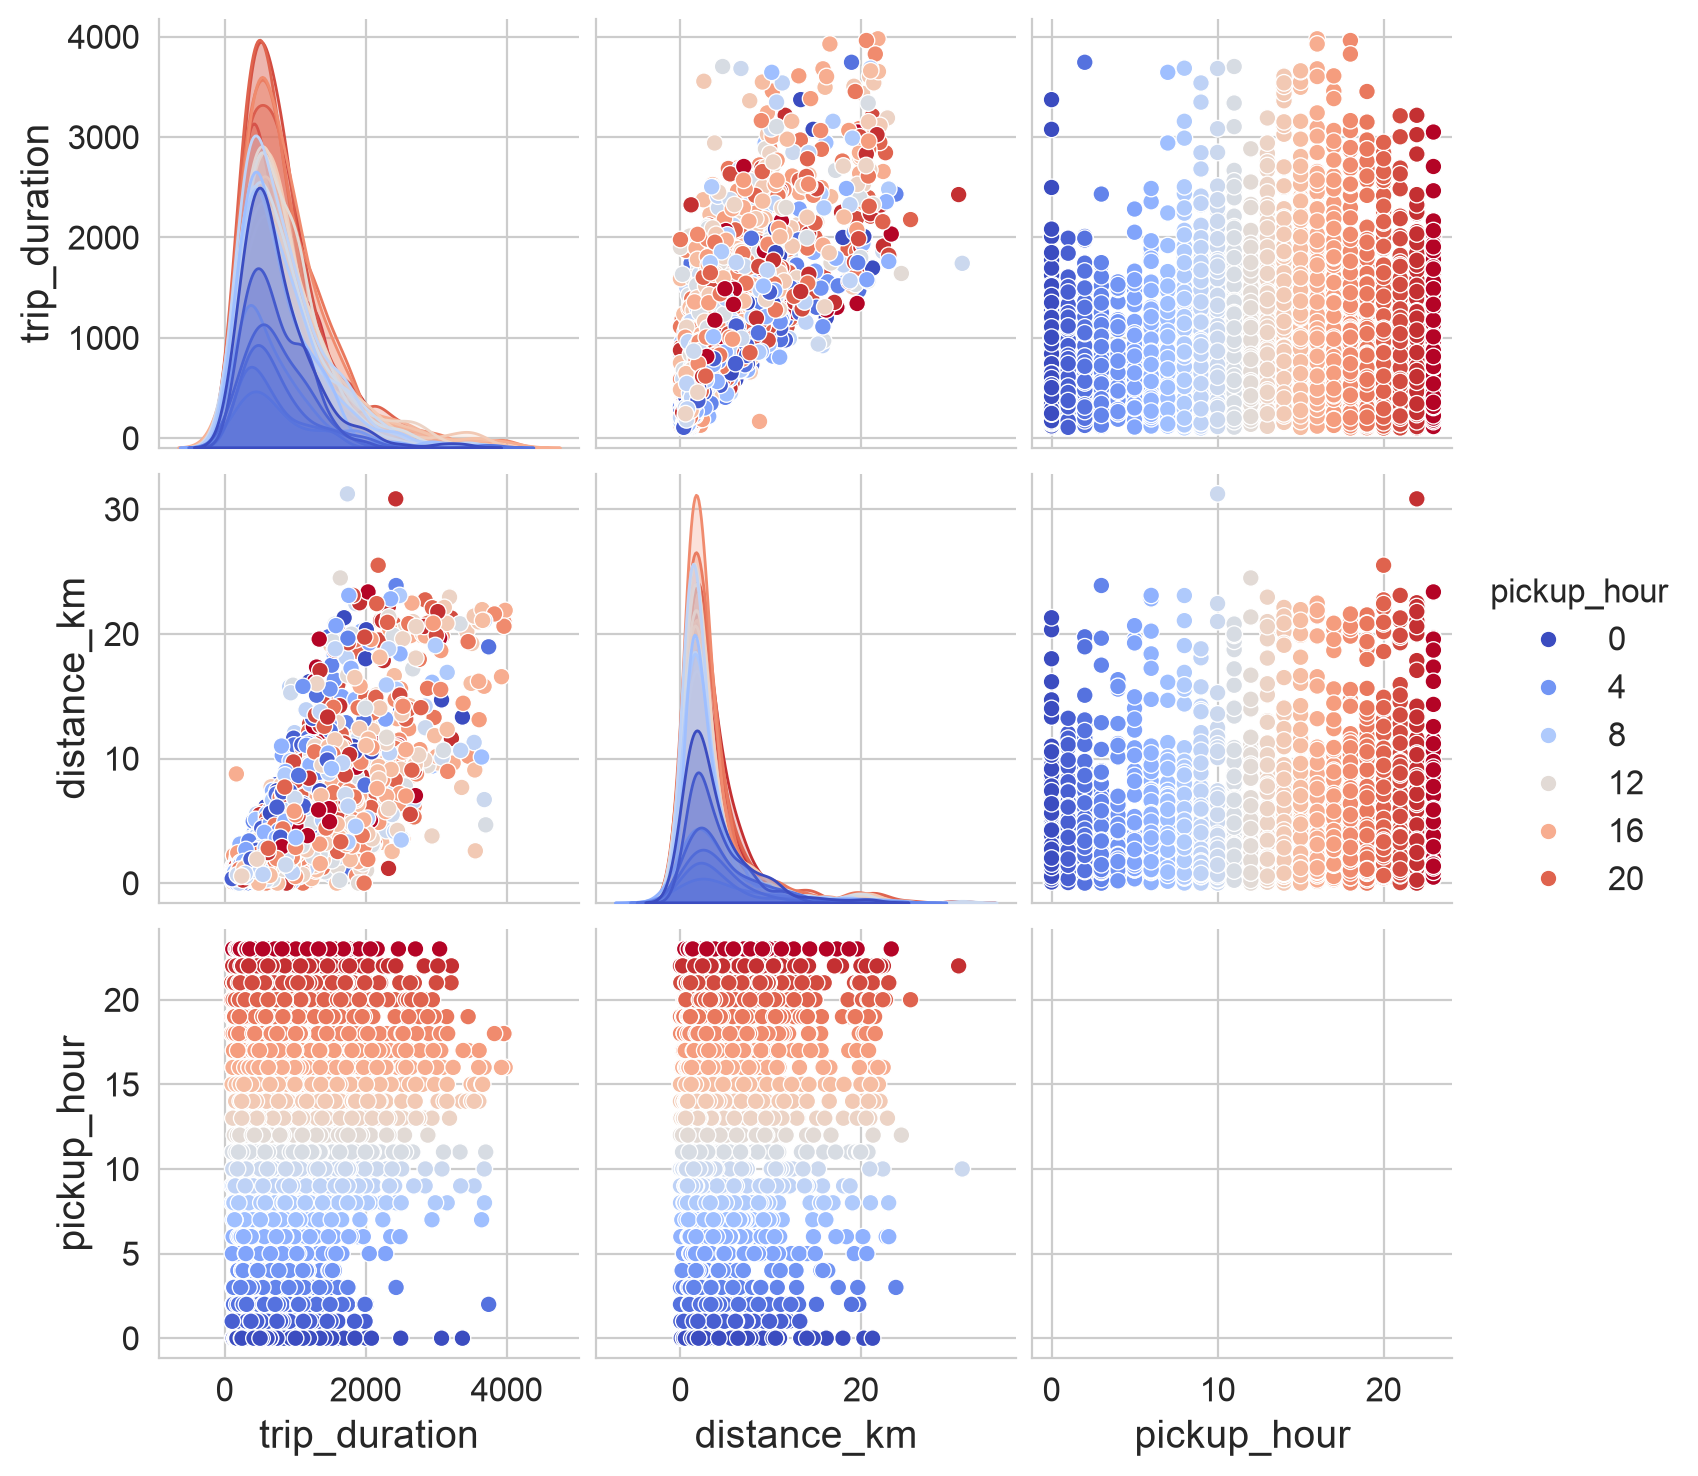

In [39]:

sns.pairplot(df.sample(5000), vars=['trip_duration', 'distance_km', 'pickup_hour', ], hue='pickup_hour', palette='coolwarm')
plt.show()

This is very interesting, we can see that small duration are usually at night, people prefer to take a taxi even for a short distance trip, maybe because it is dangerous at night.

In [40]:
df = df[df['distance_km'] > 0.1]

## More Feature Engineering

In [41]:
df["is_rush_hour"] = (
    df["pickup_hour"].isin(range(8,19))
).astype(int)

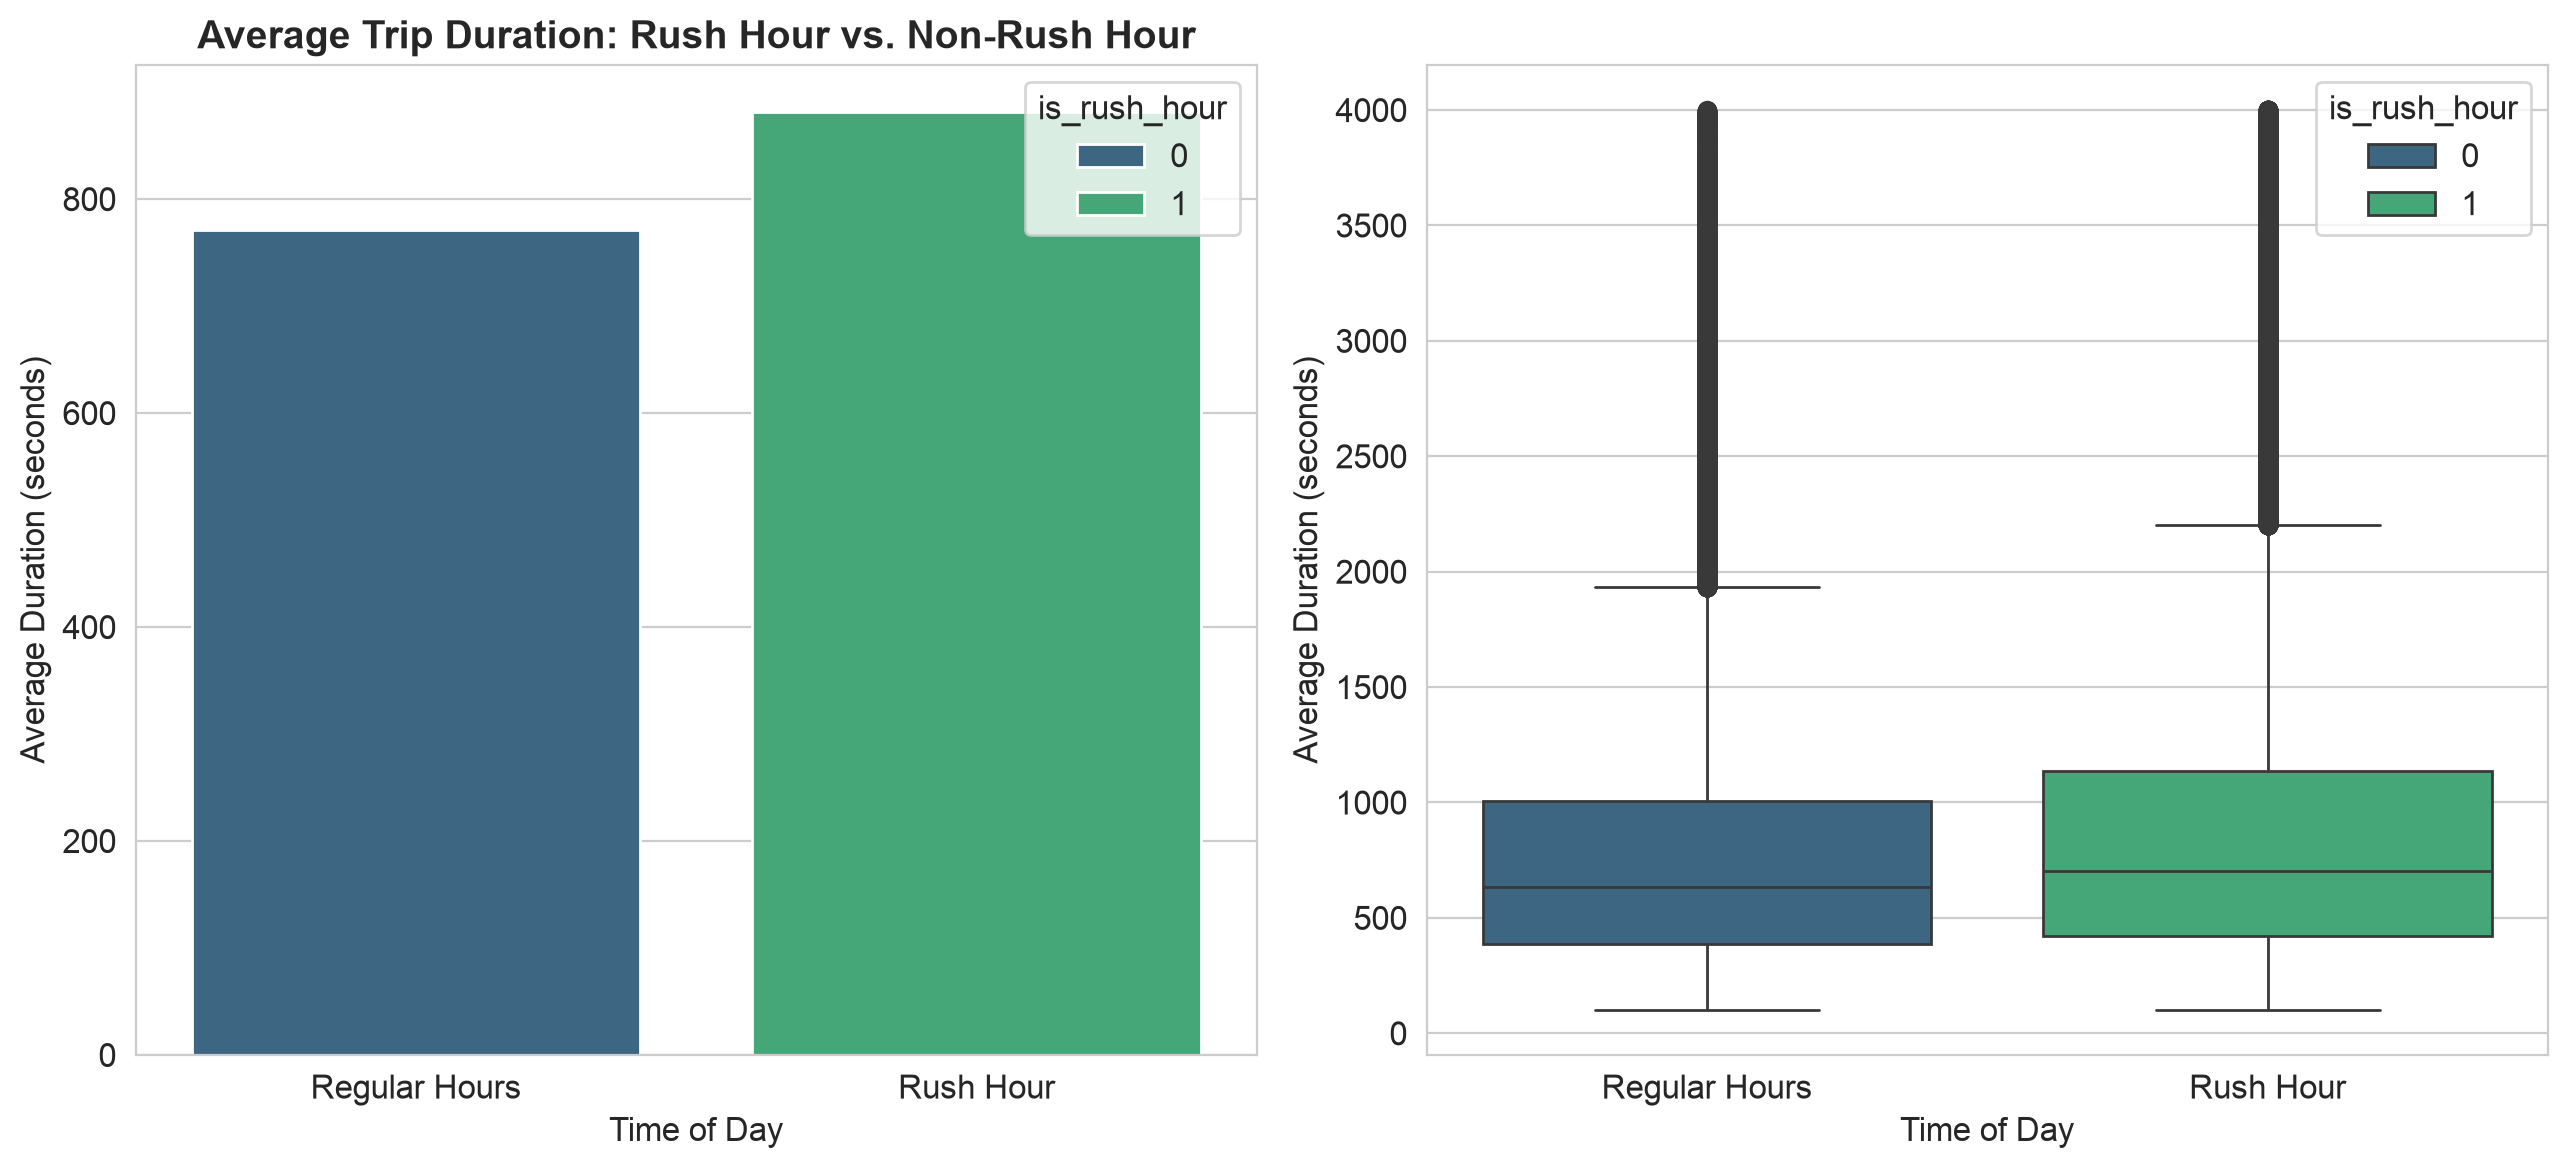

In [42]:
from scipy.sparse import data
fig, axes = plt.subplots(1, 2, figsize=(13, 6))



sns.barplot(data=df, x='is_rush_hour', y='trip_duration', hue= 'is_rush_hour',
            palette='viridis', errorbar=None, ax=axes[0])


axes[0].set_title('Average Trip Duration: Rush Hour vs. Non-Rush Hour', fontweight='bold', fontsize=14)
axes[0].set_xticks([0, 1], ['Regular Hours', 'Rush Hour'], fontsize=12)
axes[0].set_ylabel('Average Duration (seconds)', fontsize=12)
axes[0].set_xlabel('Time of Day', fontsize=12)

sns.boxplot(data=df, x='is_rush_hour', y='trip_duration', hue= 'is_rush_hour',
            palette='viridis', ax=axes[1])



axes[1].set_xticks([0, 1], ['Regular Hours', 'Rush Hour'], fontsize=12)
axes[1].set_ylabel('Average Duration (seconds)', fontsize=12)
axes[1].set_xlabel('Time of Day', fontsize=12)


plt.tight_layout()
plt.show()

In [43]:
df[df['trip_duration'] < 100]

,vendor_id,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,distance_km,is_rush_hour


> Useless feature, must be dropped.
we already engineered the distance feature and it's the most important one.
no we move to Models.

In [44]:
df.drop(columns=['is_rush_hour'], inplace=True)

> also drop is_weekend, it causes multicolinearity

In [45]:
df.drop(columns=['is_weekend' ], inplace=True)

In [46]:
# the columns left
df.info()

<class 'pandas.DataFrame'>
Index: 1424492 entries, 0 to 1458643
Data columns (total 10 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   vendor_id          1424492 non-null  int64  
 1   pickup_longitude   1424492 non-null  float64
 2   pickup_latitude    1424492 non-null  float64
 3   dropoff_longitude  1424492 non-null  float64
 4   dropoff_latitude   1424492 non-null  float64
 5   trip_duration      1424492 non-null  int64  
 6   pickup_hour        1424492 non-null  int32  
 7   pickup_dayofweek   1424492 non-null  int32  
 8   pickup_month       1424492 non-null  int32  
 9   distance_km        1424492 non-null  float64
dtypes: float64(5), int32(3), int64(2)
memory usage: 103.2 MB


## Model Training

In [47]:
x = df.drop('trip_duration', axis=1)
y = df['trip_duration']

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=14)

In [48]:
RANDOM_STATE = 14
CV_FOLDS = 5

cat_cols = ['vendor_id', 'pickup_month']
num_cols = [col for col in X_train.columns if col not in cat_cols]


In [49]:
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoding', OneHotEncoder(handle_unknown='ignore'))
])

In [50]:
preprocessor = ColumnTransformer([
    ('numeric', num_pipeline, num_cols ),
    ('categorical', cat_pipeline, cat_cols ),
])

In [51]:
from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

Models = {
    'Linear Regression': LinearRegression(),
    
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),

    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Gradient Boost': GradientBoostingRegressor(random_state=RANDOM_STATE),

    "XGBoost": XGBRegressor(
        random_state=RANDOM_STATE,
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        objective="reg:squarederror",
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        random_state=RANDOM_STATE,
        n_estimators=200,
        learning_rate=0.05
    ),

    "CatBoost": CatBoostRegressor(
        random_state=RANDOM_STATE,
        iterations=200,
        learning_rate=0.05,
        verbose=0
    )
}

In [52]:
results = []

for name, model in Models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=CV_FOLDS,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    rmse_scores = -scores
    results.append({
        "Model": name,
        "Mean RMSE": rmse_scores.mean(),
    })



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008182 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1324
[LightGBM] [Info] Number of data points in the train set: 911674, number of used features: 15
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005111 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1324
[LightGBM] [Info] Number of data points in the train set: 911674, number of used features: 15
[LightGBM] [Info] Start training from score 830.058602
[LightGBM] [Info] Start training from score 831.060975
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not

In [53]:
results_df = (
    pd.DataFrame(results).
    sort_values('Mean RMSE').
    reset_index(drop=True)
)

print(results_df)

               Model   Mean RMSE
0      Random Forest  264.727079
1           LightGBM  278.882279
2            XGBoost  280.132758
3           CatBoost  295.061495
4     Gradient Boost  309.254875
5      Decision Tree  380.131930
6  Linear Regression  436.146335


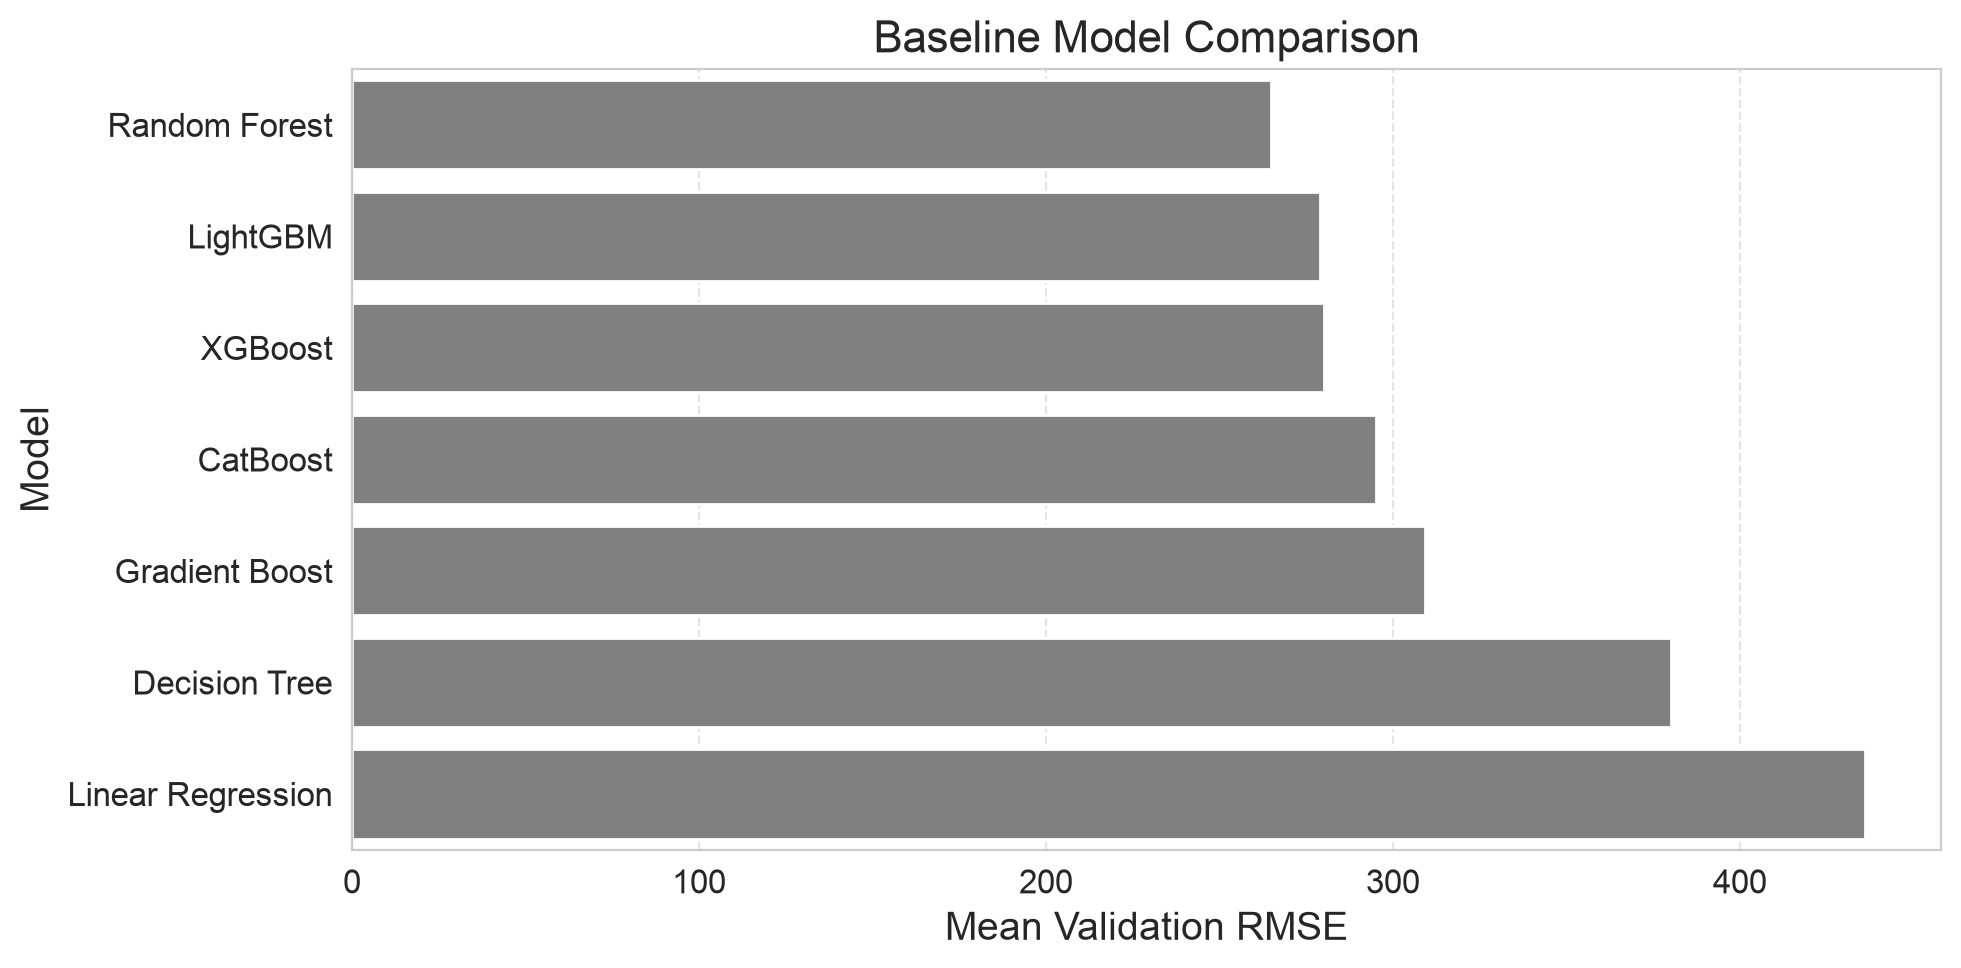

In [54]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Mean RMSE",
    y="Model",
    color="grey"
)

plt.title("Baseline Model Comparison")
plt.xlabel("Mean Validation RMSE")
plt.ylabel("Model")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Fine Tuning Random Forest

In [55]:
rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [56]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf)
])

In [57]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [20, None],
    "model__min_samples_split": [2, 5]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=CV_FOLDS,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


[CV] END model__max_depth=20, model__min_samples_split=5, model__n_estimators=100; total time=11.0min
[CV] END model__max_depth=20, model__min_samples_split=5, model__n_estimators=100; total time=11.0min


/Users/lmouh/Desktop/coding/projects/nyc-trip/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END model__max_depth=20, model__min_samples_split=2, model__n_estimators=100; total time=11.1min
[CV] END model__max_depth=20, model__min_samples_split=2, model__n_estimators=100; total time=11.2min
[CV] END model__max_depth=20, model__min_samples_split=2, model__n_estimators=100; total time=11.2min
[CV] END model__max_depth=20, model__min_samples_split=2, model__n_estimators=100; total time=11.2min
[CV] END model__max_depth=20, model__min_samples_split=2, model__n_estimators=100; total time=11.2min
[CV] END model__max_depth=20, model__min_samples_split=2, model__n_estimators=200; total time=27.5min
[CV] END model__max_depth=20, model__min_samples_split=2, model__n_estimators=200; total time=27.6min
[CV] END model__max_depth=20, model__min_samples_split=2, model__n_estimators=200; total time=27.6min
[CV] END model__max_depth=20, model__min_samples_split=2, model__n_estimators=200; total time=27.6min
[CV] END model__max_depth=20, model__min_samples_split=2, model__n_estimators=200;

In [ ]:
print("Best parameters:")
print(grid_search.best_params_)

In [ ]:
best_rmse = -grid_search.best_score_

print(f"Best CV RMSE: {best_rmse:.2f}")